# ArchitectAgent Training Dataset — Validation & Cleaning Pipeline

Dataset of ~900 JSONL rows for fine-tuning the ArchitectAgent. This notebook validates, cleans, and exports the dataset so it is fully compatible with `main.py` at runtime.

| # | Section |
|---|---|
| 0 | Setup & Configuration |
| 1 | Data Loading |
| 2 | Chain Reconstruction |
| 3 | Structural Schema Validation |
| 4 | Enum & Value Domain Compliance |
| 5 | Cross-Field Consistency |
| 6 | Plan Richness & Anti-Stub |
| 7 | Diversity & Coverage |
| 8 | Duplication Detection |
| 9 | Bias Detection |
| 10 | Chain Progression Validation |
| 11 | Plan-Contract Alignment |
| 12 | Cleaning Pipeline |
| 13 | Before vs After |
| 14 | Statistical Tests |
| 15 | LLM-as-a-Judge + Export |
| 16 | Final Key Normalization |

## 0 — Setup

In [1]:
import json
import hashlib
import re
import copy
import math
import warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 6)

print('imports ok')

imports ok


In [2]:
# All enum sets match main.py FIELD_PROMPTS exactly (snake_case)
ALLOWED_PROJECT_CLASSES = {
    'web_app', 'fullstack_app', 'mobile_app', 'desktop_app', 'api_service',
    'static_website', 'landing_page', 'cli_tool', 'library_sdk',
    'automation_tool', 'data_pipeline', 'ai_system', 'research_prototype',
    'infrastructure_project'
}

ALLOWED_CAPABILITIES = {
    'frontend', 'backend', 'data', 'auth', 'ai_llm', 'integrations',
    'analytics', 'realtime', 'payments', 'admin_panel', 'public_api',
    'batch_jobs', 'devops'
}

ALLOWED_COMPLEXITY = {'simple', 'moderate', 'advanced', 'high_scale'}
ALLOWED_RISK = {'low', 'medium', 'high'}
ALLOWED_SENSITIVITY = {'none', 'internal', 'personal', 'financial', 'health', 'confidential'}
ALLOWED_EXPOSURE = {'local_only', 'internal_only', 'private_authenticated', 'partner_facing', 'public_internet'}
ALLOWED_SEVERITY = {'critical', 'high', 'medium', 'low'}
ALLOWED_STATUS = {'unresolved', 'resolved', 'downgraded', 'new'}
ALLOWED_CASE_TYPE = {'first_pass', 'revision_round'}
ALLOWED_PLAN_QUALITY = {'low', 'moderate', 'good', 'high'}

# Compact forms that appear in the raw dataset because the generator used no underscores.
FORBIDDEN_COMPACT_VALUES = {
    'webapp', 'fullstackapp', 'mobileapp', 'desktopapp', 'apiservice',
    'staticwebsite', 'landingpage', 'clitool', 'librarysdk',
    'automationtool', 'datapipeline', 'aisystem', 'researchprototype',
    'infrastructureproject', 'localonly', 'internalonly', 'privateauthenticated',
    'partnerfacing', 'publicinternet', 'aillm', 'adminpanel', 'publicapi',
    'batchjobs', 'highscale',
}

# Profile key renames: raw dataset uses compact keys, main.py uses snake_case
PROFILE_KEY_MAP = {
    'projectclass': 'project_class',
    'complexitylevel': 'complexity_level',
    'risklevel': 'risk_level',
    'datasensitivity': 'data_sensitivity',
    'externalexposure': 'external_exposure',
}

# Compact enum value -> snake_case, covers profile fields and contract .value strings
COMPACT_VALUE_MAP = {
    'webapp': 'web_app',
    'fullstackapp': 'fullstack_app',
    'mobileapp': 'mobile_app',
    'desktopapp': 'desktop_app',
    'apiservice': 'api_service',
    'staticwebsite': 'static_website',
    'landingpage': 'landing_page',
    'clitool': 'cli_tool',
    'librarysdk': 'library_sdk',
    'automationtool': 'automation_tool',
    'datapipeline': 'data_pipeline',
    'aisystem': 'ai_system',
    'researchprototype': 'research_prototype',
    'infrastructureproject': 'infrastructure_project',
    'localonly': 'local_only',
    'internalonly': 'internal_only',
    'privateauthenticated': 'private_authenticated',
    'partnerfacing': 'partner_facing',
    'publicinternet': 'public_internet',
    'aillm': 'ai_llm',
    'adminpanel': 'admin_panel',
    'publicapi': 'public_api',
    'batchjobs': 'batch_jobs',
    'highscale': 'high_scale',
}

# Non-standard plan_quality values produced by the generator
PLAN_QUALITY_MAP = {
    'strong': 'good',
    'excellent': 'high',
    'weak': 'low',
    'adequate': 'moderate',
    'poor': 'low',
    'great': 'high',
    'fair': 'moderate',
}

MANDATORY_CONTRACT_FIELDS = [
    'project_goal', 'target_users', 'project_class', 'capabilities',
    'complexity_level', 'risk_level', 'data_sensitivity', 'external_exposure',
    'access_model', 'feature_scope', 'mvp_scope', 'security_baseline',
    'frontend_stack', 'backend_stack', 'data_platform', 'hosting_target',
    'privacy_retention_policy', 'future_scope', 'constraints',
    'observability_baseline', 'execution_preference'
]

CONTRACT_FIELD_SUBKEYS = {'value', 'source', 'confirmed', 'rationale', 'updated_at'}

# Keys that main.py normalize_plan() expects in target_output
MANDATORY_PLAN_KEYS = [
    'thinking_summary', 'fix_report', 'title', 'executive_summary',
    'architecture_overview', 'technology_stack', 'functional_feature_map',
    'system_components', 'workflows', 'data_model', 'api_design',
    'security_and_compliance', 'deployment_and_operations', 'observability',
    'cost_and_scaling', 'phased_implementation', 'development_guidelines',
    'risks_and_tradeoffs', 'open_questions_resolved'
]

PLAN_CONTENT_SECTIONS = [
    'executive_summary', 'architecture_overview', 'technology_stack',
    'functional_feature_map', 'system_components', 'workflows',
    'data_model', 'api_design', 'security_and_compliance',
    'deployment_and_operations', 'observability', 'cost_and_scaling',
    'phased_implementation', 'development_guidelines', 'risks_and_tradeoffs',
    'open_questions_resolved'
]

FIX_REPORT_ITEM_KEYS = {'issue_id', 'action_taken', 'changed_sections', 'expected_outcome'}
VALID_CHANGED_SECTIONS = set(PLAN_CONTENT_SECTIONS + ['title'])
ISSUE_LEDGER_ITEM_KEYS = {'id', 'title', 'severity', 'status', 'detail'}

# These keys belong to AuditorAgent output only and must not appear in target_output
AUDITOR_LEAK_KEYS = {
    'rubric_scores', 'rubricscores', 'requirements_alignment', 'architecture_quality',
    'blocking_issues', 'blockingissues', 'requirement_conflicts', 'requirementconflicts',
    'issue_updates', 'issueupdates', 'score', 'passed', 'penalty', 'base_score'
}

MANDATORY_PAYLOAD_KEYS = [
    'round', 'frozen_requirement_contract', 'requirements',
    'reasoner_reviews', 'specialist_subplans', 'issue_ledger',
    'focus_issues', 'revision_memory', 'accepted_exceptions',
    'previous_audits', 'previous_plan', 'best_plan'
]

REQUIRED_REQ_SECTIONS = [
    'project', 'frontend', 'backend', 'security', 'data',
    'devops', 'constraints', 'open_questions', 'confirmed_decisions'
]

STUB_PATTERNS = re.compile(
    r'^(standard|tbd|n\/a|na|todo|none|mvp|default|yes|no|ok|'
    r'as needed|best practices|see above|placeholder|pending|later)$',
    re.IGNORECASE
)
MIN_SECTION_WORDS = 25
STUB_SECTION_WORDS = 5

TECH_TERMS = [
    'kubernetes', 'k8s', 'docker', 'ecs', 'fargate', 'lambda', 'rds',
    'dynamodb', 'postgres', 'mongodb', 'redis', 'kafka', 'rabbitmq',
    'nginx', 'express', 'fastapi', 'django', 'spring', 'react', 'vue',
    'angular', 'flutter', 'swift', 'kotlin', 'terraform', 'helm',
    'argocd', 'github actions', 'datadog', 'prometheus', 'grafana',
    'cloudwatch', 'tls', 'oauth', 'oidc', 'jwt', 'auth0', 'okta',
    'mfa', 'rbac', 'waf', 's3', 'cloudfront', 'alb', 'api gateway',
    'sns', 'sqs', 'openapi', 'graphql', 'grpc', 'websocket', 'sse',
    'sqlite', 'mysql', 'elasticsearch', 'signalr', 'wpf', 'dotnet',
    'supabase', 'firebase', 'vercel', 'netlify', 'gcp', 'azure', 'aws',
    'tailwind', 'nextjs', 'nuxt', 'svelte', 'typescript', 'tensorrt',
    'yolov8', 'deepsort', 'gstreamer', 'jetson', 'tflite', 'onnx',
    'cobra', 'bubble tea', 'go embed', 'docusaurus', 'lunr',
]

DATA_PATH = 'architect_dataset.jsonl'
OUTPUT_DIR = Path('validation_output')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'data path: {DATA_PATH}')
print(f'output dir: {OUTPUT_DIR}')

data path: architect_dataset.jsonl
output dir: validation_output


## 1 — Data Loading

In [3]:
def robust_jsonl_loader(filepath):
    valid_rows = []
    errors = []
    seen_ids = set()

    def repair(text, max_iter=150):
        # attempt 1: split object — two halves of one row joined by a stray comma
        decoder = json.JSONDecoder()
        try:
            obj1, idx = decoder.raw_decode(text)
            remainder = text[idx:].strip()
            if remainder.startswith(','):
                obj1.update(json.loads('{' + remainder.lstrip(',') + '}'))
                return obj1
        except Exception:
            pass

        # attempt 2: iterative unescaped-quote and bad-escape repair
        t = text
        for _ in range(max_iter):
            try:
                return json.loads(t)
            except json.JSONDecodeError as e:
                pos = e.pos
                if e.msg == "Expecting ',' delimiter":
                    fixed = False
                    for back in range(1, 30):
                        c = pos - back
                        if c < 0:
                            break
                        if t[c] == '"':
                            n = 0
                            k = c - 1
                            while k >= 0 and t[k] == '\\':
                                n += 1
                                k -= 1
                            if n % 2 == 0:
                                t = t[:c] + '\\"' + t[c+1:]
                                fixed = True
                                break
                    if not fixed:
                        return None
                elif 'Invalid' in e.msg and 'escape' in e.msg:
                    bad = pos - 1
                    if bad >= 0:
                        t = t[:bad] + '\\\\' + t[bad+1:]
                    else:
                        return None
                else:
                    return None
        return None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                obj = repair(line)
                if obj is None:
                    errors.append({'line': line_num, 'error': 'unrecoverable'})
                    continue
            if not isinstance(obj, dict):
                continue
            sid = obj.get('sample_id', '')
            if sid and sid in seen_ids:
                errors.append({'line': line_num, 'error': f'duplicate id: {sid}'})
                continue
            if sid:
                seen_ids.add(sid)
            valid_rows.append(obj)

    return valid_rows, errors


rows, load_errors = robust_jsonl_loader(DATA_PATH)

print(f'loaded {len(rows)} rows, {len(load_errors)} errors')
if load_errors:
    for e in load_errors[:20]:
        print(f'  line {e.get("line")}: {e.get("error")}')

if rows:
    ids = [r.get('sample_id', '') for r in rows]
    print(f'id range: {ids[0]} .. {ids[-1]}')
    print(f'agents: {Counter(r.get("agent", "") for r in rows).most_common()}')
    print(f'splits: {Counter(r.get("split", "") for r in rows).most_common()}')

loaded 814 rows, 17 errors
  line 171: unrecoverable
  line 251: unrecoverable
  line 307: unrecoverable
  line 355: unrecoverable
  line 391: duplicate id: ARC-PLAN26-391
  line 392: duplicate id: ARC-PLAN26-392
  line 393: duplicate id: ARC-PLAN26-393
  line 394: duplicate id: ARC-PLAN26-394
  line 395: duplicate id: ARC-PLAN26-395
  line 396: duplicate id: ARC-PLAN26-396
  line 397: duplicate id: ARC-PLAN26-397
  line 398: duplicate id: ARC-PLAN26-398
  line 399: duplicate id: ARC-PLAN26-399
  line 400: duplicate id: ARC-PLAN26-400
  line 534: unrecoverable
  line 702: duplicate id: ARC-PLAN26-701
  line 821: duplicate id: ARC-PLAN26-822
id range: ARC-PLAN26-001 .. ARC-PLAN26-832
agents: [('ArchitectAgent', 814)]
splits: [('train', 814)]


## 2 — Chain Reconstruction

Groups rows into multi-round planning chains by hashing the frozen contract. Two rows with the same hash belong to the same planning chain and are intentional revisions, not duplicates.

total chains: 768
chain length distribution: {1: 725, 2: 40, 3: 3}
single-round: 725
multi-round: 43


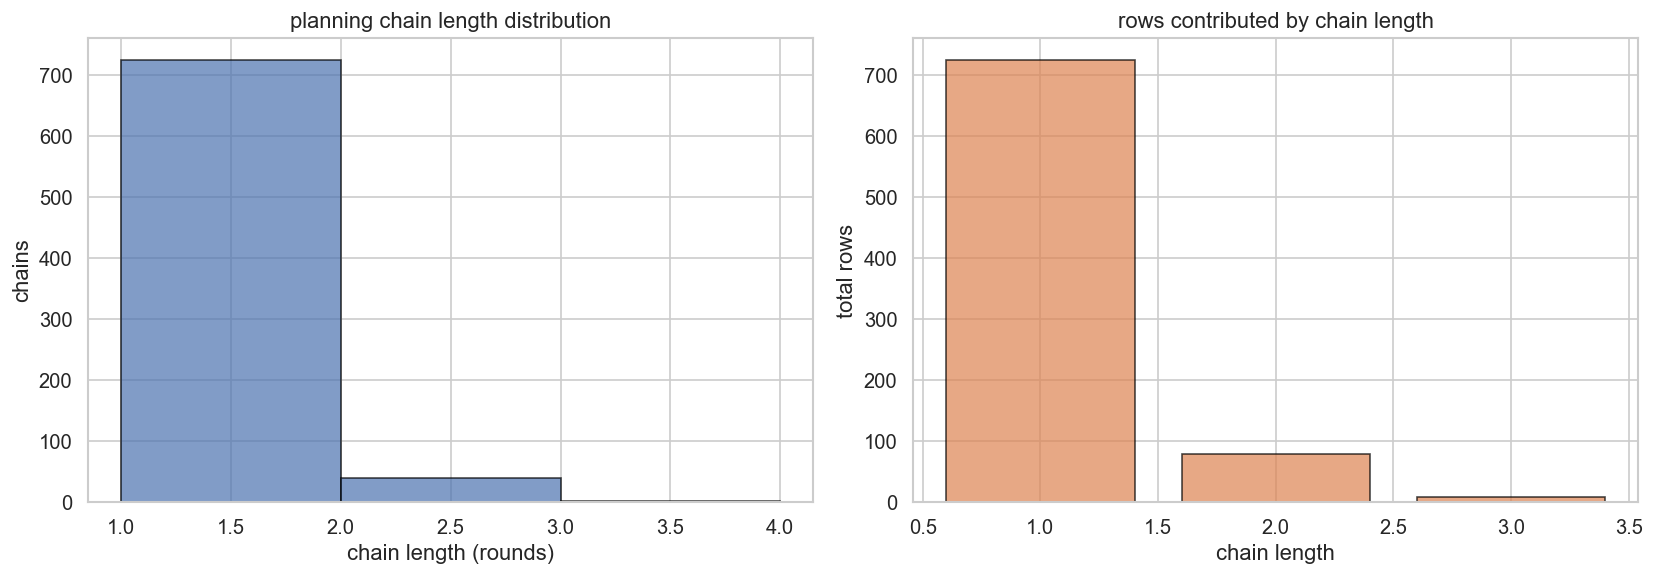

In [4]:
def get_profile_value(profile, snake_key):
    compact_key = snake_key.replace('_', '')
    return profile.get(snake_key, '') or profile.get(compact_key, '')


def contract_fingerprint(row):
    contract = row.get('input_payload', {}).get('frozen_requirement_contract', {})
    goal_field = contract.get('project_goal', {}) or contract.get('projectgoal', {})
    goal = goal_field.get('value', '') if isinstance(goal_field, dict) else str(goal_field)
    pc_field = contract.get('project_class', {}) or contract.get('projectclass', {})
    pc = pc_field.get('value', '') if isinstance(pc_field, dict) else str(pc_field)
    caps_field = contract.get('capabilities', {})
    caps = caps_field.get('value', '') if isinstance(caps_field, dict) else str(caps_field)
    raw = f'{goal.strip().lower()}|{pc.strip().lower()}|{caps.strip().lower()}'
    return hashlib.md5(raw.encode()).hexdigest()[:16]


def reconstruct_chains(rows):
    chains = defaultdict(list)
    for row in rows:
        chains[contract_fingerprint(row)].append(row)
    for fp in chains:
        chains[fp].sort(key=lambda r: r.get('input_payload', {}).get('round', 1))
    return dict(chains)


chains = reconstruct_chains(rows)
chain_lengths = [len(v) for v in chains.values()]

row_to_chain = {}
for fp, chain_rows in chains.items():
    for r in chain_rows:
        row_to_chain[r.get('sample_id', '')] = fp

print(f'total chains: {len(chains)}')
print(f'chain length distribution: {dict(sorted(Counter(chain_lengths).items()))}')
print(f'single-round: {sum(1 for l in chain_lengths if l == 1)}')
print(f'multi-round: {sum(1 for l in chain_lengths if l > 1)}')

if chains:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(chain_lengths, bins=range(1, max(chain_lengths) + 2), edgecolor='black', alpha=0.7, color='#4C72B0')
    axes[0].set_xlabel('chain length (rounds)')
    axes[0].set_ylabel('chains')
    axes[0].set_title('planning chain length distribution')
    rows_per_len = defaultdict(int)
    for v in chains.values():
        rows_per_len[len(v)] += len(v)
    lengths = sorted(rows_per_len)
    axes[1].bar(lengths, [rows_per_len[l] for l in lengths], edgecolor='black', alpha=0.7, color='#DD8452')
    axes[1].set_xlabel('chain length')
    axes[1].set_ylabel('total rows')
    axes[1].set_title('rows contributed by chain length')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'chain_distribution.png', bbox_inches='tight')
    plt.show()

## 3 — Structural Schema Validation

Checks the exact nested structure expected by `main.py`. Compact profile keys like `projectclass` are flagged as WARNING rather than ERROR since the cleaning pipeline handles the rename.

In [5]:
class SchemaValidator:
    def __init__(self):
        self.violations = []

    def reset(self):
        self.violations = []

    def add(self, severity, path, message):
        self.violations.append({'severity': severity, 'path': path, 'message': message})

    def check_type(self, value, expected_type, path, label):
        if not isinstance(value, expected_type):
            self.add('FATAL', path, f'{label} expected {expected_type.__name__}, got {type(value).__name__}')
            return False
        return True

    def check_key(self, d, key, path, severity='ERROR'):
        if key not in d:
            self.add(severity, f'{path}.{key}', f"missing key '{key}'")
            return False
        return True

    def validate_contract_field(self, field, path):
        if not isinstance(field, dict):
            self.add('FATAL', path, f'contract field must be dict, got {type(field).__name__}')
            return
        for subkey in CONTRACT_FIELD_SUBKEYS:
            if subkey not in field:
                self.add('ERROR', f'{path}.{subkey}', f"missing sub-key '{subkey}'")
        if 'confirmed' in field and not isinstance(field['confirmed'], bool):
            self.add('WARNING', f'{path}.confirmed', f'confirmed should be bool, got {type(field["confirmed"]).__name__}')

    def validate_profile(self, profile, path):
        if not self.check_type(profile, dict, path, 'profile'):
            return
        self.check_key(profile, 'domain', path)
        for compact_key, snake_key in PROFILE_KEY_MAP.items():
            if compact_key in profile:
                self.add('WARNING', f'{path}.{compact_key}',
                         f"compact key '{compact_key}' should be '{snake_key}' — will be renamed in cleaning")
            elif snake_key not in profile:
                self.add('ERROR', f'{path}.{snake_key}',
                         f"missing '{snake_key}' (compact form '{compact_key}' also absent)")
        caps = profile.get('capabilities')
        if caps is not None and not isinstance(caps, list):
            self.add('ERROR', f'{path}.capabilities', 'must be a list')

    def validate_row(self, row):
        self.reset()

        for key in {'sample_id', 'dataset', 'agent', 'split', 'profile', 'input_payload', 'target_output', 'metadata'}:
            self.check_key(row, key, 'root', 'FATAL')

        self.validate_profile(row.get('profile', {}), 'profile')

        payload = row.get('input_payload', {})
        if self.check_type(payload, dict, 'input_payload', 'input_payload'):
            for pk in MANDATORY_PAYLOAD_KEYS:
                self.check_key(payload, pk, 'input_payload')

            contract = payload.get('frozen_requirement_contract', {})
            if self.check_type(contract, dict, 'frozen_requirement_contract', 'frozen_requirement_contract'):
                for cf in MANDATORY_CONTRACT_FIELDS:
                    if cf in contract:
                        self.validate_contract_field(contract[cf], f'frozen_requirement_contract.{cf}')
                    else:
                        self.add('ERROR', f'frozen_requirement_contract.{cf}', f"missing field '{cf}'")

            reqs = payload.get('requirements', {})
            if isinstance(reqs, dict):
                for section in REQUIRED_REQ_SECTIONS:
                    if section in reqs and isinstance(reqs[section], list):
                        self.add('ERROR', f'requirements.{section}', 'must be dict, got list')

            ledger = payload.get('issue_ledger', {})
            if isinstance(ledger, dict):
                for issue_id, issue in ledger.items():
                    if isinstance(issue, dict):
                        for ik in ISSUE_LEDGER_ITEM_KEYS:
                            if ik not in issue:
                                self.add('WARNING', f'issue_ledger.{issue_id}', f"dict issue missing key '{ik}'")

            for list_key in ('focus_issues', 'previous_audits'):
                val = payload.get(list_key)
                if val is not None and not isinstance(val, list):
                    self.add('ERROR', f'input_payload.{list_key}', 'must be a list')

        output = row.get('target_output', {})
        if self.check_type(output, dict, 'target_output', 'target_output'):
            for pk in MANDATORY_PLAN_KEYS:
                self.check_key(output, pk, 'target_output')
            if 'fix_report' in output:
                if not isinstance(output['fix_report'], list):
                    self.add('ERROR', 'target_output.fix_report', 'must be a list')
                else:
                    for i, item in enumerate(output['fix_report']):
                        if isinstance(item, dict):
                            for fk in FIX_REPORT_ITEM_KEYS:
                                if fk not in item:
                                    self.add('ERROR', f'target_output.fix_report[{i}]', f"missing key '{fk}'")
                            if 'changed_sections' in item and not isinstance(item['changed_sections'], list):
                                self.add('ERROR', f'target_output.fix_report[{i}].changed_sections', 'must be a list')

        meta = row.get('metadata', {})
        if self.check_type(meta, dict, 'metadata', 'metadata'):
            for mk in ['schema_version', 'case_type', 'plan_quality', 'primary_theme',
                       'generation_source', 'quality_flags', 'notes']:
                self.check_key(meta, mk, 'metadata')

        return self.violations


if rows:
    validator = SchemaValidator()
    all_violations = {}
    violation_summary = Counter()
    rows_with_fatal = 0

    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        viols = validator.validate_row(row)
        if viols:
            all_violations[sid] = viols
            for v in viols:
                violation_summary[v['severity']] += 1
        if any(v['severity'] == 'FATAL' for v in viols):
            rows_with_fatal += 1

    clean_count = len(rows) - len(all_violations)
    print(f'total rows: {len(rows)}')
    print(f'rows with violations: {len(all_violations)} ({len(all_violations)/len(rows)*100:.1f}%)')
    print(f'rows with fatal: {rows_with_fatal}')
    print(f'clean rows: {clean_count} ({clean_count/len(rows)*100:.1f}%)')
    print(f'violation counts: {dict(violation_summary)}')

    path_counts = Counter()
    for viols in all_violations.values():
        for v in viols:
            path_counts[v['path']] += 1
    print('\ntop 15 violated paths:')
    for path, cnt in path_counts.most_common(15):
        print(f'  {path}: {cnt}')
else:
    all_violations = {}

total rows: 814
rows with violations: 814 (100.0%)
rows with fatal: 0
clean rows: 0 (0.0%)
violation counts: {'WARNING': 5186, 'ERROR': 402}

top 15 violated paths:
  profile.projectclass: 814
  profile.complexitylevel: 814
  profile.risklevel: 814
  profile.datasensitivity: 814
  profile.externalexposure: 814
  issue_ledger.ISS-1: 192
  input_payload.accepted_exceptions: 184
  target_output.open_questions_resolved: 158
  issue_ledger.ISSUE-01: 36
  issue_ledger.ISS-01: 21
  issue_ledger.ISS-02: 21
  issue_ledger.ISSUE-1: 21
  issue_ledger.ISSUE-2: 21
  issue_ledger.ISS-112: 13
  issue_ledger.ISS-101: 13


## 4 — Enum & Value Domain Compliance

Checks all enum fields against the allowed sets from `main.py`. Specifically handles:
- profile values using both compact and snake_case keys
- `plan_quality = 'strong'` and other non-standard values from the generator
- auditor key contamination in `target_output`

In [6]:
def validate_enums(row):
    issues = []
    profile = row.get('profile', {})
    payload = row.get('input_payload', {})
    output = row.get('target_output', {})
    meta = row.get('metadata', {})
    contract = payload.get('frozen_requirement_contract', {})
    ledger = payload.get('issue_ledger', {})

    pclass = get_profile_value(profile, 'project_class')
    if pclass and pclass not in ALLOWED_PROJECT_CLASSES:
        issues.append({'path': 'profile.project_class', 'value': pclass, 'type': 'invalid_project_class',
                       'fix': COMPACT_VALUE_MAP.get(pclass, 'unknown')})

    pcomplexity = get_profile_value(profile, 'complexity_level')
    if pcomplexity and pcomplexity not in ALLOWED_COMPLEXITY:
        issues.append({'path': 'profile.complexity_level', 'value': pcomplexity, 'type': 'invalid_complexity',
                       'fix': COMPACT_VALUE_MAP.get(pcomplexity, 'unknown')})

    prisk = get_profile_value(profile, 'risk_level')
    if prisk and prisk not in ALLOWED_RISK:
        issues.append({'path': 'profile.risk_level', 'value': prisk, 'type': 'invalid_risk'})

    psens = get_profile_value(profile, 'data_sensitivity')
    if psens and psens not in ALLOWED_SENSITIVITY:
        issues.append({'path': 'profile.data_sensitivity', 'value': psens, 'type': 'invalid_sensitivity'})

    pexpose = get_profile_value(profile, 'external_exposure')
    if pexpose and pexpose not in ALLOWED_EXPOSURE:
        issues.append({'path': 'profile.external_exposure', 'value': pexpose, 'type': 'invalid_exposure',
                       'fix': COMPACT_VALUE_MAP.get(pexpose, 'unknown')})

    caps_list = profile.get('capabilities', [])
    if isinstance(caps_list, list):
        for cap in caps_list:
            if cap and cap not in ALLOWED_CAPABILITIES:
                issues.append({'path': 'profile.capabilities', 'value': cap, 'type': 'invalid_capability',
                               'fix': COMPACT_VALUE_MAP.get(cap, 'unknown')})

    enum_contract_fields = {
        'project_class': ALLOWED_PROJECT_CLASSES,
        'complexity_level': ALLOWED_COMPLEXITY,
        'risk_level': ALLOWED_RISK,
        'data_sensitivity': ALLOWED_SENSITIVITY,
        'external_exposure': ALLOWED_EXPOSURE,
    }
    for field, allowed in enum_contract_fields.items():
        cfield = contract.get(field, {})
        cval = cfield.get('value', '') if isinstance(cfield, dict) else ''
        if cval and cval not in allowed:
            issues.append({'path': f'contract.{field}', 'value': cval, 'type': 'invalid_contract_enum',
                           'fix': COMPACT_VALUE_MAP.get(cval, 'unknown')})

    for issue_id, issue in ledger.items():
        if isinstance(issue, dict):
            sev = issue.get('severity', '')
            if sev and sev not in ALLOWED_SEVERITY:
                issues.append({'path': f'issue_ledger.{issue_id}.severity', 'value': sev, 'type': 'invalid_severity'})
            st = issue.get('status', '')
            if st and st not in ALLOWED_STATUS:
                issues.append({'path': f'issue_ledger.{issue_id}.status', 'value': st, 'type': 'invalid_status'})

    ct = meta.get('case_type', '')
    if ct and ct not in ALLOWED_CASE_TYPE:
        issues.append({'path': 'metadata.case_type', 'value': ct, 'type': 'invalid_case_type'})

    pq = meta.get('plan_quality', '')
    if pq and pq not in ALLOWED_PLAN_QUALITY:
        fix = PLAN_QUALITY_MAP.get(pq, 'good')
        issues.append({'path': 'metadata.plan_quality', 'value': pq, 'type': 'invalid_plan_quality',
                       'fix': fix, 'detail': f"'{pq}' not in allowed set, will remap to '{fix}'"})

    raw_str = json.dumps(row).lower()
    for forbidden in FORBIDDEN_COMPACT_VALUES:
        pattern = r'\b' + re.escape(forbidden) + r'\b'
        if re.search(pattern, raw_str):
            issues.append({'path': 'global', 'value': forbidden, 'type': 'compact_form_detected',
                           'fix': COMPACT_VALUE_MAP.get(forbidden, 'see COMPACT_VALUE_MAP')})

    for leak_key in AUDITOR_LEAK_KEYS:
        if leak_key in output:
            issues.append({'path': f'target_output.{leak_key}', 'value': leak_key, 'type': 'auditor_key_leak'})

    for section in PLAN_CONTENT_SECTIONS:
        val = output.get(section, '')
        if isinstance(val, str) and val.strip():
            if STUB_PATTERNS.match(val.strip()):
                issues.append({'path': f'target_output.{section}', 'value': val.strip()[:50],
                               'type': 'stub_section_pattern'})
            elif len(val.split()) <= STUB_SECTION_WORDS:
                issues.append({'path': f'target_output.{section}', 'value': f'{len(val.split())} words',
                               'type': 'stub_section_too_short'})

    return issues


if rows:
    enum_results = {}
    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        issues = validate_enums(row)
        if issues:
            enum_results[sid] = issues

    print(f'rows with enum violations: {len(enum_results)} ({len(enum_results)/len(rows)*100:.1f}%)')

    type_counts = Counter()
    for sid, issues in enum_results.items():
        for iss in issues:
            type_counts[iss['type']] += 1
    print('\nviolation type counts:')
    for t, c in type_counts.most_common():
        print(f'  {t}: {c}')

    pq_values = Counter(r.get('metadata', {}).get('plan_quality', '') for r in rows)
    print('\nplan_quality distribution:')
    for val, cnt in pq_values.most_common():
        status = 'ok' if val in ALLOWED_PLAN_QUALITY else f'fix -> {PLAN_QUALITY_MAP.get(val, "?")}'   
        print(f"  '{val}': {cnt}  [{status}]")
else:
    enum_results = {}

rows with enum violations: 814 (100.0%)

violation type counts:
  compact_form_detected: 1883
  invalid_contract_enum: 1711
  invalid_project_class: 814
  invalid_exposure: 814
  invalid_plan_quality: 746
  invalid_capability: 185
  invalid_complexity: 83
  stub_section_too_short: 23
  invalid_sensitivity: 5

plan_quality distribution:
  'strong': 674  [fix -> good]
  'moderate': 68  [ok]
  'weak': 41  [fix -> low]
  'flawed': 31  [fix -> ?]


## 5 — Cross-Field Consistency

Checks logical rules that span multiple fields: first_pass vs revision_round invariants, fix_report issue ID references, focus_issues integrity, conditional contract fields.

In [7]:
def validate_cross_field(row):
    issues = []
    profile = row.get('profile', {})
    payload = row.get('input_payload', {})
    output = row.get('target_output', {})
    meta = row.get('metadata', {})
    contract = payload.get('frozen_requirement_contract', {})
    ledger = payload.get('issue_ledger', {})
    round_num = payload.get('round', 1)
    case_type = meta.get('case_type', '')

    caps_list = profile.get('capabilities', [])
    norm_caps = {COMPACT_VALUE_MAP.get(c, c) for c in (caps_list if isinstance(caps_list, list) else [])}
    risk = get_profile_value(profile, 'risk_level')
    sensitivity = get_profile_value(profile, 'data_sensitivity')

    if 'ai_llm' in norm_caps and 'llm_integration' not in contract:
        issues.append({'rule': 'conditional_llm_integration', 'severity': 'ERROR',
                       'detail': "capabilities includes 'ai_llm' but contract missing 'llm_integration'"})

    exposure = get_profile_value(profile, 'external_exposure')
    needs_compliance = (
        risk == 'high' or
        sensitivity in {'health', 'financial', 'confidential'} or
        exposure in {'public_internet', 'publicinternet', 'partner_facing', 'partnerfacing'}
    )
    if needs_compliance and 'compliance_context' not in contract:
        issues.append({'rule': 'conditional_compliance_context', 'severity': 'WARNING',
                       'detail': 'high-risk/sensitive profile but contract missing compliance_context'})

    if case_type == 'first_pass':
        if round_num != 1:
            issues.append({'rule': 'firstpass_round', 'severity': 'ERROR',
                           'detail': f'first_pass must have round=1, got {round_num}'})
        if payload.get('previous_audits'):
            issues.append({'rule': 'firstpass_no_prev_audits', 'severity': 'ERROR',
                           'detail': 'first_pass must have empty previous_audits'})
        fix_report = output.get('fix_report', [])
        if isinstance(fix_report, list) and len(fix_report) > 0:
            issues.append({'rule': 'firstpass_no_fix_report', 'severity': 'WARNING',
                           'detail': f'first_pass should have empty fix_report but has {len(fix_report)} items'})

    if case_type == 'revision_round':
        if round_num < 2:
            issues.append({'rule': 'revision_round_num', 'severity': 'ERROR',
                           'detail': f'revision_round must have round>=2, got {round_num}'})
        fix_report = output.get('fix_report', [])
        if isinstance(fix_report, list) and len(fix_report) == 0:
            issues.append({'rule': 'revision_needs_fix_report', 'severity': 'ERROR',
                           'detail': 'revision_round must have non-empty fix_report'})
        if not ledger:
            issues.append({'rule': 'revision_needs_issue_ledger', 'severity': 'ERROR',
                           'detail': 'revision_round must have non-empty issue_ledger'})

    fix_report = output.get('fix_report', [])
    if isinstance(fix_report, list) and isinstance(ledger, dict):
        ledger_ids = set(ledger.keys())
        for item in fix_report:
            if isinstance(item, dict):
                fid = item.get('issue_id', '')
                if fid and fid not in ledger_ids:
                    issues.append({'rule': 'fixreport_orphan_id', 'severity': 'ERROR',
                                   'detail': f"fix_report references '{fid}' not in issue_ledger"})

    if isinstance(fix_report, list):
        for item in fix_report:
            if isinstance(item, dict):
                for section in (item.get('changed_sections') or []):
                    if section and section not in VALID_CHANGED_SECTIONS:
                        issues.append({'rule': 'fixreport_invalid_section', 'severity': 'WARNING',
                                       'detail': f"changed_section '{section}' is not a valid plan section"})

    focus = payload.get('focus_issues', [])
    if isinstance(focus, list) and isinstance(ledger, dict):
        ledger_ids = set(ledger.keys())
        for fi in focus:
            fid = fi.get('id', '') if isinstance(fi, dict) else str(fi)
            if fid and fid not in ledger_ids:
                issues.append({'rule': 'focus_issue_orphan', 'severity': 'WARNING',
                               'detail': f"focus issue '{fid}' not in issue_ledger"})

    rev_mem = payload.get('revision_memory', {})
    if isinstance(rev_mem, dict) and isinstance(ledger, dict):
        ledger_ids = set(ledger.keys())
        for resolved_id in rev_mem.get('resolved_issue_ids', []):
            if resolved_id not in ledger_ids:
                issues.append({'rule': 'revmem_resolved_orphan', 'severity': 'WARNING',
                               'detail': f"revision_memory references resolved issue '{resolved_id}' not in ledger"})

    return issues


if rows:
    cross_results = {}
    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        issues = validate_cross_field(row)
        if issues:
            cross_results[sid] = issues

    print(f'rows with cross-field issues: {len(cross_results)} ({len(cross_results)/len(rows)*100:.1f}%)')
    rule_counts = Counter()
    for issues in cross_results.values():
        for iss in issues:
            rule_counts[iss['rule']] += 1
    print('\nrule violation counts:')
    for rule, cnt in rule_counts.most_common():
        print(f'  {rule}: {cnt}')
else:
    cross_results = {}

rows with cross-field issues: 308 (37.8%)

rule violation counts:
  conditional_compliance_context: 297
  fixreport_invalid_section: 20
  conditional_llm_integration: 8


## 6 — Plan Richness & Anti-Stub

mean words: 817
median words: 846
mean tech hits: 10.3
mean richness score: 64.9/80
rows with at least one stub section: 171

top stub-prone sections:
  open_questions_resolved: 163
  observability: 7
  api_design: 6
  cost_and_scaling: 4
  development_guidelines: 3
  deployment_and_operations: 1


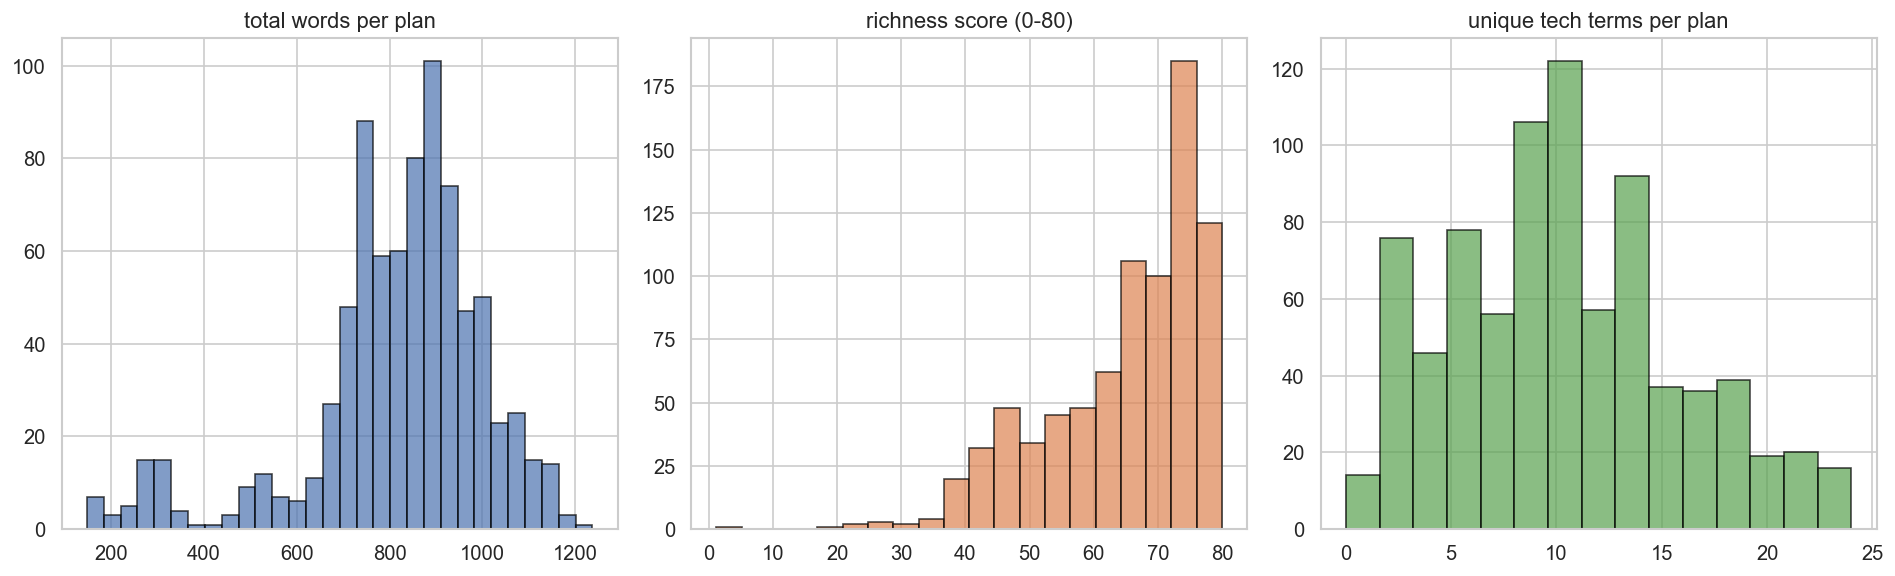

In [8]:
def compute_richness(row):
    output = row.get('target_output', {})
    section_stats = {}
    total_words = 0
    stub_count = 0
    tech_hits = 0
    full_text = ''

    for section in PLAN_CONTENT_SECTIONS:
        val = output.get(section, '')
        text = json.dumps(val) if not isinstance(val, str) else val
        words = len(text.split())
        is_stub = words <= STUB_SECTION_WORDS or (isinstance(val, str) and STUB_PATTERNS.match(val.strip()))
        section_stats[section] = {'words': words, 'stub': is_stub}
        total_words += words
        if is_stub:
            stub_count += 1
        full_text += ' ' + text

    full_lower = full_text.lower()
    for term in TECH_TERMS:
        if term in full_lower:
            tech_hits += 1

    word_score = min(total_words / 1000, 1.0) * 50
    tech_score = min(tech_hits / 8, 1.0) * 30
    stub_penalty = stub_count * 5
    richness = max(0, word_score + tech_score - stub_penalty)

    return {
        'total_words': total_words,
        'tech_hits': tech_hits,
        'stub_count': stub_count,
        'richness_score': round(richness, 2),
        'sections': section_stats,
    }


def plan_text(row):
    output = row.get('target_output', {})
    return ' '.join([
        str(output.get('executive_summary', '')),
        str(output.get('architecture_overview', '')),
        str(output.get('technology_stack', '')),
    ])


if rows:
    richness_data = []
    for row in rows:
        r = compute_richness(row)
        r['sample_id'] = row.get('sample_id', '')
        r['project_class'] = get_profile_value(row.get('profile', {}), 'project_class')
        r['plan_quality'] = row.get('metadata', {}).get('plan_quality', '')
        richness_data.append(r)

    df_rich = pd.DataFrame(richness_data)

    print(f'mean words: {df_rich["total_words"].mean():.0f}')
    print(f'median words: {df_rich["total_words"].median():.0f}')
    print(f'mean tech hits: {df_rich["tech_hits"].mean():.1f}')
    print(f'mean richness score: {df_rich["richness_score"].mean():.1f}/80')
    print(f'rows with at least one stub section: {(df_rich["stub_count"] > 0).sum()}')

    stub_section_counts = Counter()
    for r in richness_data:
        for sec, stat in r['sections'].items():
            if stat['stub']:
                stub_section_counts[sec] += 1
    if stub_section_counts:
        print('\ntop stub-prone sections:')
        for sec, cnt in stub_section_counts.most_common(8):
            print(f'  {sec}: {cnt}')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].hist(df_rich['total_words'], bins=30, edgecolor='black', alpha=0.7, color='#4C72B0')
    axes[0].set_title('total words per plan')
    axes[1].hist(df_rich['richness_score'], bins=20, edgecolor='black', alpha=0.7, color='#DD8452')
    axes[1].set_title('richness score (0-80)')
    axes[2].hist(df_rich['tech_hits'], bins=15, edgecolor='black', alpha=0.7, color='#59A14F')
    axes[2].set_title('unique tech terms per plan')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'richness_distribution.png', bbox_inches='tight')
    plt.show()
else:
    df_rich = pd.DataFrame()

## 7 — Diversity & Coverage

project classes found: 16 / 14
class entropy: 3.491 / 3.807 (91.7% of max)

project class counts:
  api_service                    180
  web_app                        117
  data_pipeline                  72
  cli_tool                       67
  mobile_app                     65
  ai_system                      54
  automation_tool                52
  fullstack_app                  46
  infrastructure_project         42
  library_sdk                    40
  desktop_app                    30
  landing_page                   16
  research_prototype             16
  static_website                 15
  backend                        1
  batch_jobs                     1

capabilities found: 18 / 13
top 10 capabilities:
  data                 508
  backend              455
  integrations         319
  frontend             290
  realtime             204
  auth                 173
  analytics            114
  devops               95
  ai_llm               76
  payments             62


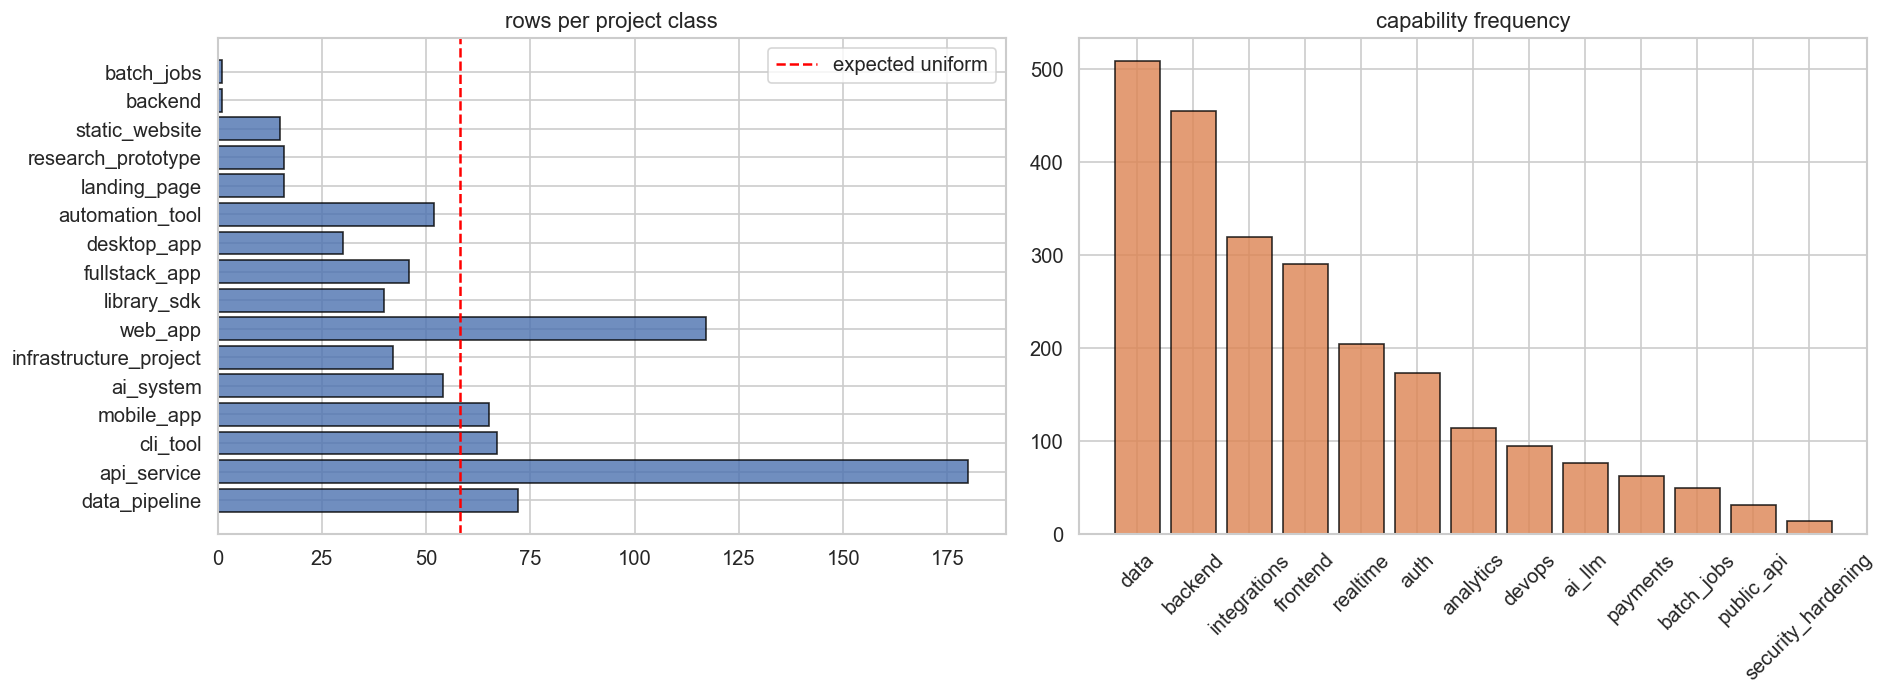

In [9]:
def shannon_entropy(counter):
    total = sum(counter.values())
    if total == 0:
        return 0.0
    return -sum((v / total) * math.log2(v / total) for v in counter.values() if v > 0)


if rows:
    raw_classes = [get_profile_value(r.get('profile', {}), 'project_class') for r in rows]
    norm_classes = [COMPACT_VALUE_MAP.get(c, c) for c in raw_classes]
    class_counts = Counter(norm_classes)

    all_caps = []
    for r in rows:
        caps = r.get('profile', {}).get('capabilities', [])
        if isinstance(caps, list):
            all_caps.extend(COMPACT_VALUE_MAP.get(c, c) for c in caps)
    cap_counts = Counter(all_caps)

    class_entropy = shannon_entropy(class_counts)
    max_class_entropy = math.log2(len(ALLOWED_PROJECT_CLASSES))

    print(f'project classes found: {len(class_counts)} / {len(ALLOWED_PROJECT_CLASSES)}')
    print(f'class entropy: {class_entropy:.3f} / {max_class_entropy:.3f} ({class_entropy/max_class_entropy*100:.1f}% of max)')
    print('\nproject class counts:')
    for cls, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
        print(f'  {cls:<30} {cnt}')

    missing = ALLOWED_PROJECT_CLASSES - set(class_counts.keys())
    if missing:
        print(f'\nmissing classes: {missing}')

    print(f'\ncapabilities found: {len(cap_counts)} / {len(ALLOWED_CAPABILITIES)}')
    print('top 10 capabilities:')
    for cap, cnt in cap_counts.most_common(10):
        print(f'  {cap:<20} {cnt}')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    classes = list(class_counts.keys())
    counts = [class_counts[c] for c in classes]
    axes[0].barh(classes, counts, color='#4C72B0', edgecolor='black', alpha=0.8)
    axes[0].set_title('rows per project class')
    axes[0].axvline(len(rows) / len(ALLOWED_PROJECT_CLASSES), color='red', linestyle='--', label='expected uniform')
    axes[0].legend()
    cap_names = [c for c, _ in cap_counts.most_common(13)]
    cap_vals = [cap_counts[c] for c in cap_names]
    axes[1].bar(cap_names, cap_vals, color='#DD8452', edgecolor='black', alpha=0.8)
    axes[1].set_title('capability frequency')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'diversity_coverage.png', bbox_inches='tight')
    plt.show()

## 8 — Duplication Detection

Two passes: structural fingerprint for exact matches, then TF-IDF cosine similarity for near-duplicates. Same-chain rows are skipped since they are intentional revisions.

In [10]:
def row_fingerprint(row):
    profile = row.get('profile', {})
    pc = COMPACT_VALUE_MAP.get(get_profile_value(profile, 'project_class'), get_profile_value(profile, 'project_class'))
    exp = COMPACT_VALUE_MAP.get(get_profile_value(profile, 'external_exposure'), get_profile_value(profile, 'external_exposure'))
    caps = sorted(
        COMPACT_VALUE_MAP.get(c, c)
        for c in (profile.get('capabilities', []) if isinstance(profile.get('capabilities', []), list) else [])
    )
    rnd = row.get('input_payload', {}).get('round', 1)
    goal_raw = row.get('input_payload', {}).get('frozen_requirement_contract', {}).get('project_goal', {})
    goal_val = goal_raw.get('value', '') if isinstance(goal_raw, dict) else str(goal_raw)
    goal_hash = hashlib.md5(goal_val.strip().lower().encode()).hexdigest()[:8]
    key = f'{pc}|{exp}|{",".join(caps)}|r{rnd}|{goal_hash}'
    return hashlib.md5(key.encode()).hexdigest()


if rows:
    fp_counts = Counter(row_fingerprint(r) for r in rows)
    structural_dupes = {fp for fp, cnt in fp_counts.items() if cnt > 1}
    struct_dupe_rows = [r for r in rows if row_fingerprint(r) in structural_dupes]

    print(f'structural duplicate fingerprints: {len(structural_dupes)}')
    print(f'rows in structural dup clusters: {len(struct_dupe_rows)}')

    texts = [plan_text(r) for r in rows]
    sample_ids = [r.get('sample_id', '') for r in rows]
    semantic_dupe_pairs = []

    if len(texts) > 1:
        try:
            vect = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words='english')
            tfidf_matrix = vect.fit_transform(texts)
            BATCH = 200
            for i in range(0, len(rows), BATCH):
                batch = tfidf_matrix[i:i+BATCH]
                sims = cosine_similarity(batch, tfidf_matrix)
                for bi, row_sims in enumerate(sims):
                    gi = i + bi
                    chain_id = row_to_chain.get(sample_ids[gi], '')
                    for gj, sim in enumerate(row_sims):
                        if gj <= gi:
                            continue
                        if row_to_chain.get(sample_ids[gj], '') == chain_id:
                            continue
                        if sim > 0.88:
                            semantic_dupe_pairs.append((sample_ids[gi], sample_ids[gj], round(sim, 3)))
            print(f'\nsemantic near-duplicate pairs (sim>0.88, cross-chain): {len(semantic_dupe_pairs)}')
            for a, b, sim in sorted(semantic_dupe_pairs, key=lambda x: -x[2])[:10]:
                print(f'  {a} <-> {b}  sim={sim:.3f}')
        except Exception as e:
            print(f'tf-idf similarity skipped: {e}')

structural duplicate fingerprints: 34
rows in structural dup clusters: 70

semantic near-duplicate pairs (sim>0.88, cross-chain): 102
  ARC-PLAN26-811 <-> ARC-PLAN26-821  sim=1.000
  ARC-PLAN26-805 <-> ARC-PLAN26-825  sim=0.998
  ARC-PLAN26-672 <-> ARC-PLAN26-682  sim=0.997
  ARC-PLAN26-672 <-> ARC-PLAN26-692  sim=0.997
  ARC-PLAN26-675 <-> ARC-PLAN26-684  sim=0.996
  ARC-PLAN26-806 <-> ARC-PLAN26-826  sim=0.994
  ARC-PLAN26-817 <-> ARC-PLAN26-827  sim=0.994
  ARC-PLAN26-788 <-> ARC-PLAN26-798  sim=0.993
  ARC-PLAN26-417 <-> ARC-PLAN26-422  sim=0.992
  ARC-PLAN26-670 <-> ARC-PLAN26-680  sim=0.992


## 9 — Bias Detection

anova (word count by project class): F=5.464  p=0.0000
  significant bias — longest: backend (970 words), shortest: api_service (732 words)

top 10 tech terms by frequency:
  aws                       404 (49.6%)
  sse                       343 (42.1%)
  postgres                  330 (40.5%)
  redis                     323 (39.7%)
  rds                       289 (35.5%)
  react                     224 (27.5%)
  tls                       178 (21.9%)
  s3                        177 (21.7%)
  tailwind                  166 (20.4%)
  ecs                       164 (20.1%)

length-quality correlation: r=-0.145  p=0.0001


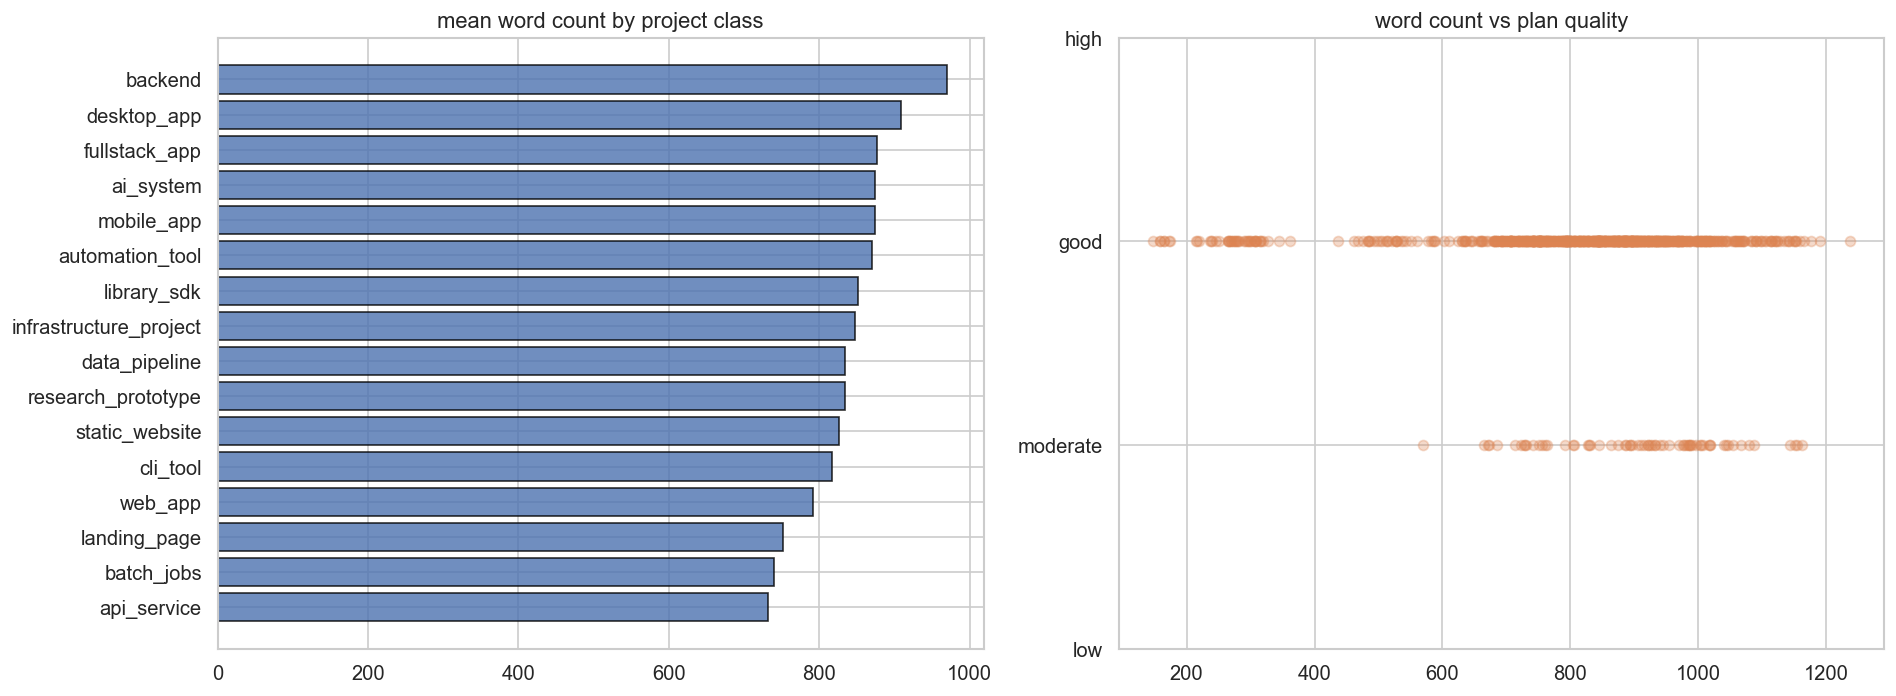

In [11]:
if rows and not df_rich.empty:
    df_rich['norm_class'] = df_rich['project_class'].apply(lambda c: COMPACT_VALUE_MAP.get(c, c))

    groups = [df_rich[df_rich['norm_class'] == cls]['total_words'].values
              for cls in df_rich['norm_class'].unique() if len(df_rich[df_rich['norm_class'] == cls]) > 2]
    if len(groups) > 1:
        f_stat, p_val = stats.f_oneway(*groups)
        print(f'anova (word count by project class): F={f_stat:.3f}  p={p_val:.4f}')
        if p_val < 0.05:
            means = df_rich.groupby('norm_class')['total_words'].mean().sort_values(ascending=False)
            print(f'  significant bias — longest: {means.index[0]} ({means.iloc[0]:.0f} words), shortest: {means.index[-1]} ({means.iloc[-1]:.0f} words)')
        else:
            print('  no significant word-count bias')

    tech_word_counts = Counter()
    for row in rows:
        text = plan_text(row).lower()
        for term in TECH_TERMS:
            if term in text:
                tech_word_counts[term] += 1
    print('\ntop 10 tech terms by frequency:')
    for term, cnt in tech_word_counts.most_common(10):
        print(f'  {term:<25} {cnt} ({cnt/len(rows)*100:.1f}%)')

    pq_map = {'low': 1, 'moderate': 2, 'good': 3, 'high': 4, 'strong': 3, 'excellent': 4}
    df_rich['pq_num'] = df_rich['plan_quality'].map(pq_map)
    valid = df_rich.dropna(subset=['pq_num'])
    if len(valid) > 10:
        corr, corr_p = stats.pearsonr(valid['total_words'], valid['pq_num'])
        print(f'\nlength-quality correlation: r={corr:.3f}  p={corr_p:.4f}')
        if abs(corr) > 0.3 and corr_p < 0.05:
            print('  significant correlation — quality labels may be biased by plan length')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    means_by_class = df_rich.groupby('norm_class')['total_words'].mean().sort_values()
    axes[0].barh(means_by_class.index, means_by_class.values, color='#4C72B0', edgecolor='black', alpha=0.8)
    axes[0].set_title('mean word count by project class')
    axes[1].scatter(valid['total_words'], valid['pq_num'], alpha=0.3, color='#DD8452')
    axes[1].set_title('word count vs plan quality')
    axes[1].set_yticks([1, 2, 3, 4])
    axes[1].set_yticklabels(['low', 'moderate', 'good', 'high'])
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'bias_analysis.png', bbox_inches='tight')
    plt.show()

## 10 — Chain Progression Validation

In [12]:
if chains:
    chain_issues = []
    for fp, chain_rows in chains.items():
        if len(chain_rows) < 2:
            continue
        rounds = [r.get('input_payload', {}).get('round', 0) for r in chain_rows]
        for i in range(1, len(rounds)):
            if rounds[i] <= rounds[i - 1]:
                chain_issues.append({'chain': fp, 'type': 'non_ascending_rounds',
                                     'detail': f'round {rounds[i]} follows {rounds[i-1]}'})
        for i in range(1, len(chain_rows)):
            prev_ledger = set(chain_rows[i - 1].get('input_payload', {}).get('issue_ledger', {}).keys())
            curr_fix = chain_rows[i].get('target_output', {}).get('fix_report', [])
            if isinstance(curr_fix, list):
                for item in curr_fix:
                    if isinstance(item, dict):
                        fid = item.get('issue_id', '')
                        if fid and prev_ledger and fid not in prev_ledger:
                            chain_issues.append({'chain': fp, 'type': 'fix_references_unknown_issue',
                                                 'detail': f"round {rounds[i]} fix references '{fid}' not in prev round ledger"})

    print(f'multi-round chains validated: {sum(1 for c in chains.values() if len(c) > 1)}')
    print(f'chain progression issues: {len(chain_issues)}')
    issue_type_counts = Counter(i['type'] for i in chain_issues)
    for t, c in issue_type_counts.most_common():
        print(f'  {t}: {c}')

multi-round chains validated: 43
chain progression issues: 39
  non_ascending_rounds: 38
  fix_references_unknown_issue: 1


## 11 — Plan-Contract Alignment

In [13]:
def contract_alignment_score(row):
    contract = row.get('input_payload', {}).get('frozen_requirement_contract', {})
    output = row.get('target_output', {})
    plan_text_full = ' '.join(str(output.get(s, '')) for s in PLAN_CONTENT_SECTIONS).lower()

    hits = 0
    checks = 0
    for field_name, field_obj in contract.items():
        if not isinstance(field_obj, dict):
            continue
        val = str(field_obj.get('value', '')).strip().lower()
        if len(val) < 5:
            continue
        checks += 1
        if val in plan_text_full:
            hits += 1
    return (hits / checks) if checks > 0 else 0.0


if rows:
    alignment_scores = [contract_alignment_score(r) for r in rows]
    sample_ids_list = [r.get('sample_id', '') for r in rows]
    low_alignment = [(sid, s) for sid, s in zip(sample_ids_list, alignment_scores) if s < 0.15]

    print(f'mean alignment score: {sum(alignment_scores)/len(alignment_scores):.3f}')
    print(f'median alignment: {sorted(alignment_scores)[len(alignment_scores)//2]:.3f}')
    print(f'low-alignment rows (<0.15): {len(low_alignment)} ({len(low_alignment)/len(rows)*100:.1f}%)')
    if low_alignment:
        print(f'examples: {[sid for sid, _ in low_alignment[:5]]}')

mean alignment score: 0.113
median alignment: 0.100
low-alignment rows (<0.15): 557 (68.4%)
examples: ['ARC-PLAN26-001', 'ARC-PLAN26-003', 'ARC-PLAN26-004', 'ARC-PLAN26-005', 'ARC-PLAN26-007']


## 12 — Cleaning Pipeline

Applies fixes in order:
1. Profile key rename — `projectclass` -> `project_class` etc.
2. Profile value remap — `aisystem` -> `ai_system` etc.
3. Contract field value remap — same compact->snake for values inside contract fields
4. `plan_quality` remap — `strong` -> `good` etc.
5. Missing payload key injection — `accepted_exceptions`, `focus_issues` etc.
6. Missing output key injection — `open_questions_resolved`, `fix_report`
7. Auditor key removal from `target_output`
8. Requirements section structure fix

In [14]:
def normalize_profile_keys(profile):
    for compact_key, snake_key in PROFILE_KEY_MAP.items():
        if compact_key in profile and snake_key not in profile:
            profile[snake_key] = profile.pop(compact_key)
    return profile


def normalize_profile_values(profile):
    for key in ('project_class', 'external_exposure', 'complexity_level'):
        val = profile.get(key, '')
        if val and val in COMPACT_VALUE_MAP:
            profile[key] = COMPACT_VALUE_MAP[val]
    caps = profile.get('capabilities', [])
    if isinstance(caps, list):
        profile['capabilities'] = [COMPACT_VALUE_MAP.get(c, c) for c in caps]
    return profile


def normalize_contract_values(contract):
    for field_name, field_obj in contract.items():
        if not isinstance(field_obj, dict):
            continue
        val = field_obj.get('value', '')
        if isinstance(val, str) and val in COMPACT_VALUE_MAP:
            field_obj['value'] = COMPACT_VALUE_MAP[val]
        if field_name == 'capabilities' and isinstance(val, str):
            parts = [p.strip() for p in val.replace(',', ' ').split()]
            normed = [COMPACT_VALUE_MAP.get(p, p) for p in parts if p]
            if normed != parts:
                field_obj['value'] = ', '.join(normed)
    return contract


def inject_missing_payload_keys(payload):
    defaults = {
        'accepted_exceptions': {},
        'focus_issues': [],
        'previous_audits': [],
        'previous_plan': {},
        'best_plan': {},
        'revision_memory': {},
    }
    for key, default in defaults.items():
        if key not in payload:
            payload[key] = default
    return payload


def inject_missing_output_keys(output):
    if 'open_questions_resolved' not in output:
        output['open_questions_resolved'] = []
    if 'fix_report' not in output:
        output['fix_report'] = []
    if 'thinking_summary' not in output:
        output['thinking_summary'] = ''
    return output


def remove_auditor_leaks(output):
    removed = 0
    for key in list(output.keys()):
        if key in AUDITOR_LEAK_KEYS:
            del output[key]
            removed += 1
    return output, removed


def normalize_plan_quality(meta):
    pq = meta.get('plan_quality', '')
    if pq and pq not in ALLOWED_PLAN_QUALITY:
        meta['plan_quality'] = PLAN_QUALITY_MAP.get(pq, 'good')
    return meta


def fix_requirements_structure(requirements):
    for section in REQUIRED_REQ_SECTIONS:
        if section not in requirements:
            requirements[section] = {}
        elif isinstance(requirements[section], list):
            requirements[section] = {str(i): v for i, v in enumerate(requirements[section])}
    return requirements


def clean_row(row):
    row = copy.deepcopy(row)
    changes = []

    profile = row.get('profile', {})
    before_keys = set(profile.keys())
    profile = normalize_profile_keys(profile)
    if set(profile.keys()) != before_keys:
        changes.append('profile_keys_renamed')

    before_vals = {k: profile.get(k) for k in ('project_class', 'external_exposure', 'complexity_level', 'capabilities')}
    profile = normalize_profile_values(profile)
    after_vals = {k: profile.get(k) for k in before_vals}
    if before_vals != after_vals:
        changes.append('profile_values_normalized')
    row['profile'] = profile

    payload = row.get('input_payload', {})
    contract = payload.get('frozen_requirement_contract', {})
    payload['frozen_requirement_contract'] = normalize_contract_values(contract)
    payload = inject_missing_payload_keys(payload)

    reqs = payload.get('requirements', {})
    if isinstance(reqs, dict):
        payload['requirements'] = fix_requirements_structure(reqs)
    row['input_payload'] = payload

    output = row.get('target_output', {})
    before_output_keys = set(output.keys())
    output = inject_missing_output_keys(output)
    added_keys = set(output.keys()) - before_output_keys
    if added_keys:
        changes.append(f'injected_output_keys:{added_keys}')
    output, n_leaks = remove_auditor_leaks(output)
    if n_leaks:
        changes.append(f'removed_{n_leaks}_auditor_keys')
    row['target_output'] = output

    meta = row.get('metadata', {})
    pq_before = meta.get('plan_quality', '')
    meta = normalize_plan_quality(meta)
    if meta.get('plan_quality') != pq_before:
        changes.append(f"plan_quality:{pq_before}->{meta['plan_quality']}")
    row['metadata'] = meta

    return row, changes


if rows:
    cleaned_rows = []
    all_changes = {}
    change_type_counts = Counter()
    rows_changed = 0

    for row in rows:
        cleaned, changes = clean_row(row)
        cleaned_rows.append(cleaned)
        sid = row.get('sample_id', 'UNKNOWN')
        if changes:
            all_changes[sid] = changes
            rows_changed += 1
            for c in changes:
                change_type_counts[c.split(':')[0]] += 1

    print(f'total rows: {len(rows)}')
    print(f'rows changed: {rows_changed} ({rows_changed/len(rows)*100:.1f}%)')
    print(f'rows unchanged: {len(rows) - rows_changed}')
    print('\nchange types:')
    for ctype, cnt in change_type_counts.most_common():
        print(f'  {ctype}: {cnt}')

    post_enum_issues = sum(1 for r in cleaned_rows if validate_enums(r))
    print(f'\npost-clean enum violations: {post_enum_issues}')

    missing_plan_keys = sum(
        1 for r in cleaned_rows
        if any(k not in r.get('target_output', {}) for k in MANDATORY_PLAN_KEYS)
    )
    print(f'rows still missing plan keys: {missing_plan_keys}')
else:
    cleaned_rows = []

total rows: 814
rows changed: 814 (100.0%)
rows unchanged: 0

change types:
  profile_keys_renamed: 814
  profile_values_normalized: 814
  plan_quality: 746
  injected_output_keys: 158

post-clean enum violations: 91
rows still missing plan keys: 3


## 13 — Before vs After

metric                                    before        after      delta
------------------------------------------------------------------------
  rows                                       814           814          +0
  enum violation rate                   100.00%       11.18%    -88.82%
  schema violation rate                 100.00%       39.56%    -60.44%
  mean richness score                     64.870        64.870      +0.000
  mean word count                            817           817          +0
  mean plan quality                        2.828         2.816      -0.012

plan_quality before: {'strong': 674, 'moderate': 68, 'weak': 41, 'flawed': 31}
plan_quality after:  {'good': 705, 'moderate': 68, 'low': 41}


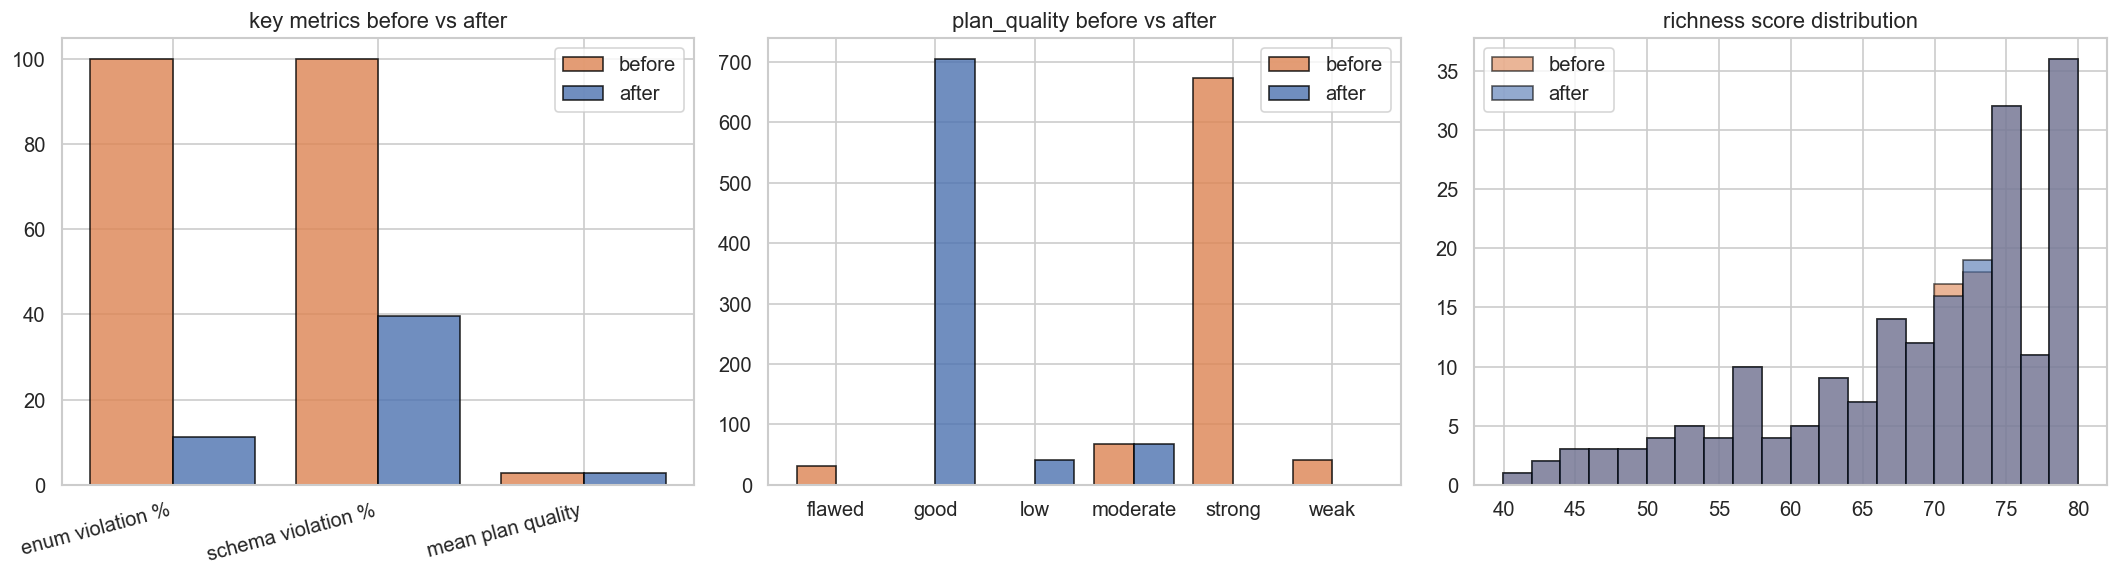

In [15]:
def compute_dataset_metrics(dataset_rows, label):
    if not dataset_rows:
        return {}
    pq_map = {'low': 1, 'moderate': 2, 'good': 3, 'high': 4, 'strong': 3, 'excellent': 4}
    enum_violation_rate = sum(1 for r in dataset_rows if validate_enums(r)) / len(dataset_rows)
    schema_violation_rate = sum(1 for r in dataset_rows if SchemaValidator().validate_row(r)) / len(dataset_rows)
    richness_scores = [compute_richness(r)['richness_score'] for r in dataset_rows]
    word_counts = [compute_richness(r)['total_words'] for r in dataset_rows]
    pq_scores = [pq_map.get(r.get('metadata', {}).get('plan_quality', ''), 2) for r in dataset_rows]
    return {
        'label': label,
        'n_rows': len(dataset_rows),
        'enum_violation_rate': round(enum_violation_rate, 4),
        'schema_violation_rate': round(schema_violation_rate, 4),
        'mean_richness': round(sum(richness_scores)/len(richness_scores), 2),
        'mean_words': round(sum(word_counts)/len(word_counts), 0),
        'mean_pq_score': round(sum(pq_scores)/len(pq_scores), 3),
        'pq_dist': dict(Counter(r.get('metadata', {}).get('plan_quality', '') for r in dataset_rows)),
    }


if rows and cleaned_rows:
    before_metrics = compute_dataset_metrics(rows, 'before')
    after_metrics = compute_dataset_metrics(cleaned_rows, 'after')

    print(f'{"metric":<35} {"before":>12} {"after":>12} {"delta":>10}')
    print('-' * 72)
    metrics = [
        ('rows', 'n_rows', 'd'),
        ('enum violation rate', 'enum_violation_rate', '%'),
        ('schema violation rate', 'schema_violation_rate', '%'),
        ('mean richness score', 'mean_richness', 'f'),
        ('mean word count', 'mean_words', 'd'),
        ('mean plan quality', 'mean_pq_score', 'f'),
    ]
    for label, key, fmt in metrics:
        bv = before_metrics.get(key, 0)
        av = after_metrics.get(key, 0)
        delta = av - bv
        if fmt == '%':
            print(f'  {label:<33} {bv*100:>10.2f}%  {av*100:>10.2f}%  {delta*100:>+8.2f}%')
        elif fmt == 'd':
            print(f'  {label:<33} {bv:>12.0f}  {av:>12.0f}  {delta:>+10.0f}')
        else:
            print(f'  {label:<33} {bv:>12.3f}  {av:>12.3f}  {delta:>+10.3f}')

    print(f'\nplan_quality before: {before_metrics.get("pq_dist", {})}')
    print(f'plan_quality after:  {after_metrics.get("pq_dist", {})}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metric_names = ['enum violation %', 'schema violation %', 'mean plan quality']
    b_vals = [before_metrics['enum_violation_rate']*100,
              before_metrics['schema_violation_rate']*100,
              before_metrics['mean_pq_score']]
    a_vals = [after_metrics['enum_violation_rate']*100,
              after_metrics['schema_violation_rate']*100,
              after_metrics['mean_pq_score']]
    x = range(len(metric_names))
    axes[0].bar([i - 0.2 for i in x], b_vals, 0.4, label='before', color='#DD8452', alpha=0.8, edgecolor='black')
    axes[0].bar([i + 0.2 for i in x], a_vals, 0.4, label='after', color='#4C72B0', alpha=0.8, edgecolor='black')
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(metric_names, rotation=15, ha='right')
    axes[0].set_title('key metrics before vs after')
    axes[0].legend()

    before_pq = Counter(r.get('metadata', {}).get('plan_quality', '') for r in rows)
    after_pq = Counter(r.get('metadata', {}).get('plan_quality', '') for r in cleaned_rows)
    all_pq_vals = sorted(set(list(before_pq.keys()) + list(after_pq.keys())))
    x2 = range(len(all_pq_vals))
    axes[1].bar([i - 0.2 for i in x2], [before_pq.get(v, 0) for v in all_pq_vals], 0.4,
                label='before', color='#DD8452', alpha=0.8, edgecolor='black')
    axes[1].bar([i + 0.2 for i in x2], [after_pq.get(v, 0) for v in all_pq_vals], 0.4,
                label='after', color='#4C72B0', alpha=0.8, edgecolor='black')
    axes[1].set_xticks(list(x2))
    axes[1].set_xticklabels(all_pq_vals)
    axes[1].set_title('plan_quality before vs after')
    axes[1].legend()

    n_sample = min(200, len(rows))
    before_rich = [compute_richness(rows[i])['richness_score'] for i in range(n_sample)]
    after_rich = [compute_richness(cleaned_rows[i])['richness_score'] for i in range(n_sample)]
    axes[2].hist(before_rich, bins=20, alpha=0.6, label='before', color='#DD8452', edgecolor='black')
    axes[2].hist(after_rich, bins=20, alpha=0.6, label='after', color='#4C72B0', edgecolor='black')
    axes[2].set_title('richness score distribution')
    axes[2].legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'before_after_comparison.png', bbox_inches='tight')
    plt.show()

## 14 — Statistical Tests

In [16]:
if rows and cleaned_rows:
    from scipy.stats import wilcoxon, chi2_contingency

    n = min(len(rows), len(cleaned_rows))
    before_rich = [compute_richness(rows[i])['richness_score'] for i in range(n)]
    after_rich = [compute_richness(cleaned_rows[i])['richness_score'] for i in range(n)]

    if len(set(a - b for a, b in zip(after_rich, before_rich))) > 1:
        stat, p = wilcoxon(before_rich, after_rich)
        print(f'wilcoxon (richness before vs after): stat={stat:.3f}  p={p:.4f}')
        print('  significant' if p < 0.05 else '  no significant difference (expected for key-only cleaning)')
    else:
        print('wilcoxon skipped — richness unchanged by key normalization (expected)')

    pq_order = ['low', 'moderate', 'good', 'high']
    before_pq = Counter(r.get('metadata', {}).get('plan_quality', '') for r in rows)
    after_pq = Counter(r.get('metadata', {}).get('plan_quality', '') for r in cleaned_rows)

    active_pq = [q for q in pq_order if before_pq.get(q, 0) > 0 or after_pq.get(q, 0) > 0]
    obs_before = [before_pq.get(q, 0) for q in active_pq]
    obs_after = [after_pq.get(q, 0) for q in active_pq]

    print(f'active plan_quality categories: {active_pq}')
    print(f'before: {dict(zip(active_pq, obs_before))}')
    print(f'after:  {dict(zip(active_pq, obs_after))}')

    if len(active_pq) >= 2 and any(v > 0 for v in obs_before) and any(v > 0 for v in obs_after):
        table = np.array([obs_before, obs_after], dtype=float)
        col_sums = table.sum(axis=0)
        table = table[:, col_sums > 0]
        if table.shape[1] >= 2:
            chi2, p_chi, dof, _ = chi2_contingency(table)
            print(f'\nchi-squared (plan_quality shift): chi2={chi2:.3f}  p={p_chi:.4f}  dof={dof}')
            if p_chi < 0.05:
                print("  significant shift — 'strong' remapping worked")
            else:
                print('  no significant shift')
        else:
            print('chi-squared skipped — only one non-zero category remaining after filtering')
    else:
        print('chi-squared skipped — not enough active categories')

    wc_list = [compute_richness(r)['total_words'] for r in cleaned_rows]
    align_list = [contract_alignment_score(r) for r in cleaned_rows]
    if len(wc_list) > 10:
        r_corr, p_corr = stats.pearsonr(wc_list, align_list)
        print(f'\npearson (word count vs contract alignment): r={r_corr:.3f}  p={p_corr:.4f}')
        if abs(r_corr) > 0.3 and p_corr < 0.05:
            direction = 'better' if r_corr > 0 else 'worse'
            print(f'  significant — longer plans have {direction} contract alignment')
        else:
            print('  independent — no meaningful correlation')

wilcoxon (richness before vs after): stat=0.000  p=0.0000
  significant
active plan_quality categories: ['low', 'moderate', 'good']
before: {'low': 0, 'moderate': 68, 'good': 0}
after:  {'low': 41, 'moderate': 68, 'good': 705}

chi-squared (plan_quality shift): chi2=404.160  p=0.0000  dof=2
  significant shift — 'strong' remapping worked

pearson (word count vs contract alignment): r=0.033  p=0.3518
  independent — no meaningful correlation


## 15 — LLM-as-a-Judge + Export

Uses Azure OpenAI to score each row across 6 architect-specific dimensions. Rows below the threshold are dropped from the final dataset.

running llm judge on 814 rows
endpoint: https://cmg-ai-poc-eu2.openai.azure.com/
deployment: gpt-5-chat
[1/814] ARC-PLAN26-001: 9/10 | KEEP
[2/814] ARC-PLAN26-002: 9/10 | KEEP
[3/814] ARC-PLAN26-003: 9/10 | KEEP
[4/814] ARC-PLAN26-004: 9/10 | KEEP
[5/814] ARC-PLAN26-005: 9/10 | KEEP
[6/814] ARC-PLAN26-006: 9/10 | KEEP
[7/814] ARC-PLAN26-007: 9/10 | KEEP
[8/814] ARC-PLAN26-008: 9/10 | KEEP
[9/814] ARC-PLAN26-009: 9/10 | KEEP
[10/814] ARC-PLAN26-010: 7/10 | NEEDS_REPAIR
[11/814] ARC-PLAN26-011: 9/10 | KEEP
[12/814] ARC-PLAN26-012: 9/10 | KEEP
[13/814] ARC-PLAN26-013: 9/10 | KEEP
[14/814] ARC-PLAN26-014: 9/10 | KEEP
[15/814] ARC-PLAN26-015: 9/10 | KEEP
[16/814] ARC-PLAN26-016: 9/10 | KEEP
[17/814] ARC-PLAN26-017: 9/10 | KEEP
[18/814] ARC-PLAN26-018: 9/10 | KEEP
[19/814] ARC-PLAN26-019: 9/10 | KEEP
[20/814] ARC-PLAN26-020: 9/10 | KEEP
[21/814] ARC-PLAN26-021: 9/10 | KEEP
[22/814] ARC-PLAN26-022: 9/10 | KEEP
[23/814] ARC-PLAN26-023: 9/10 | KEEP
[24/814] ARC-PLAN26-024: 9/10 | KEEP
[25/814] 

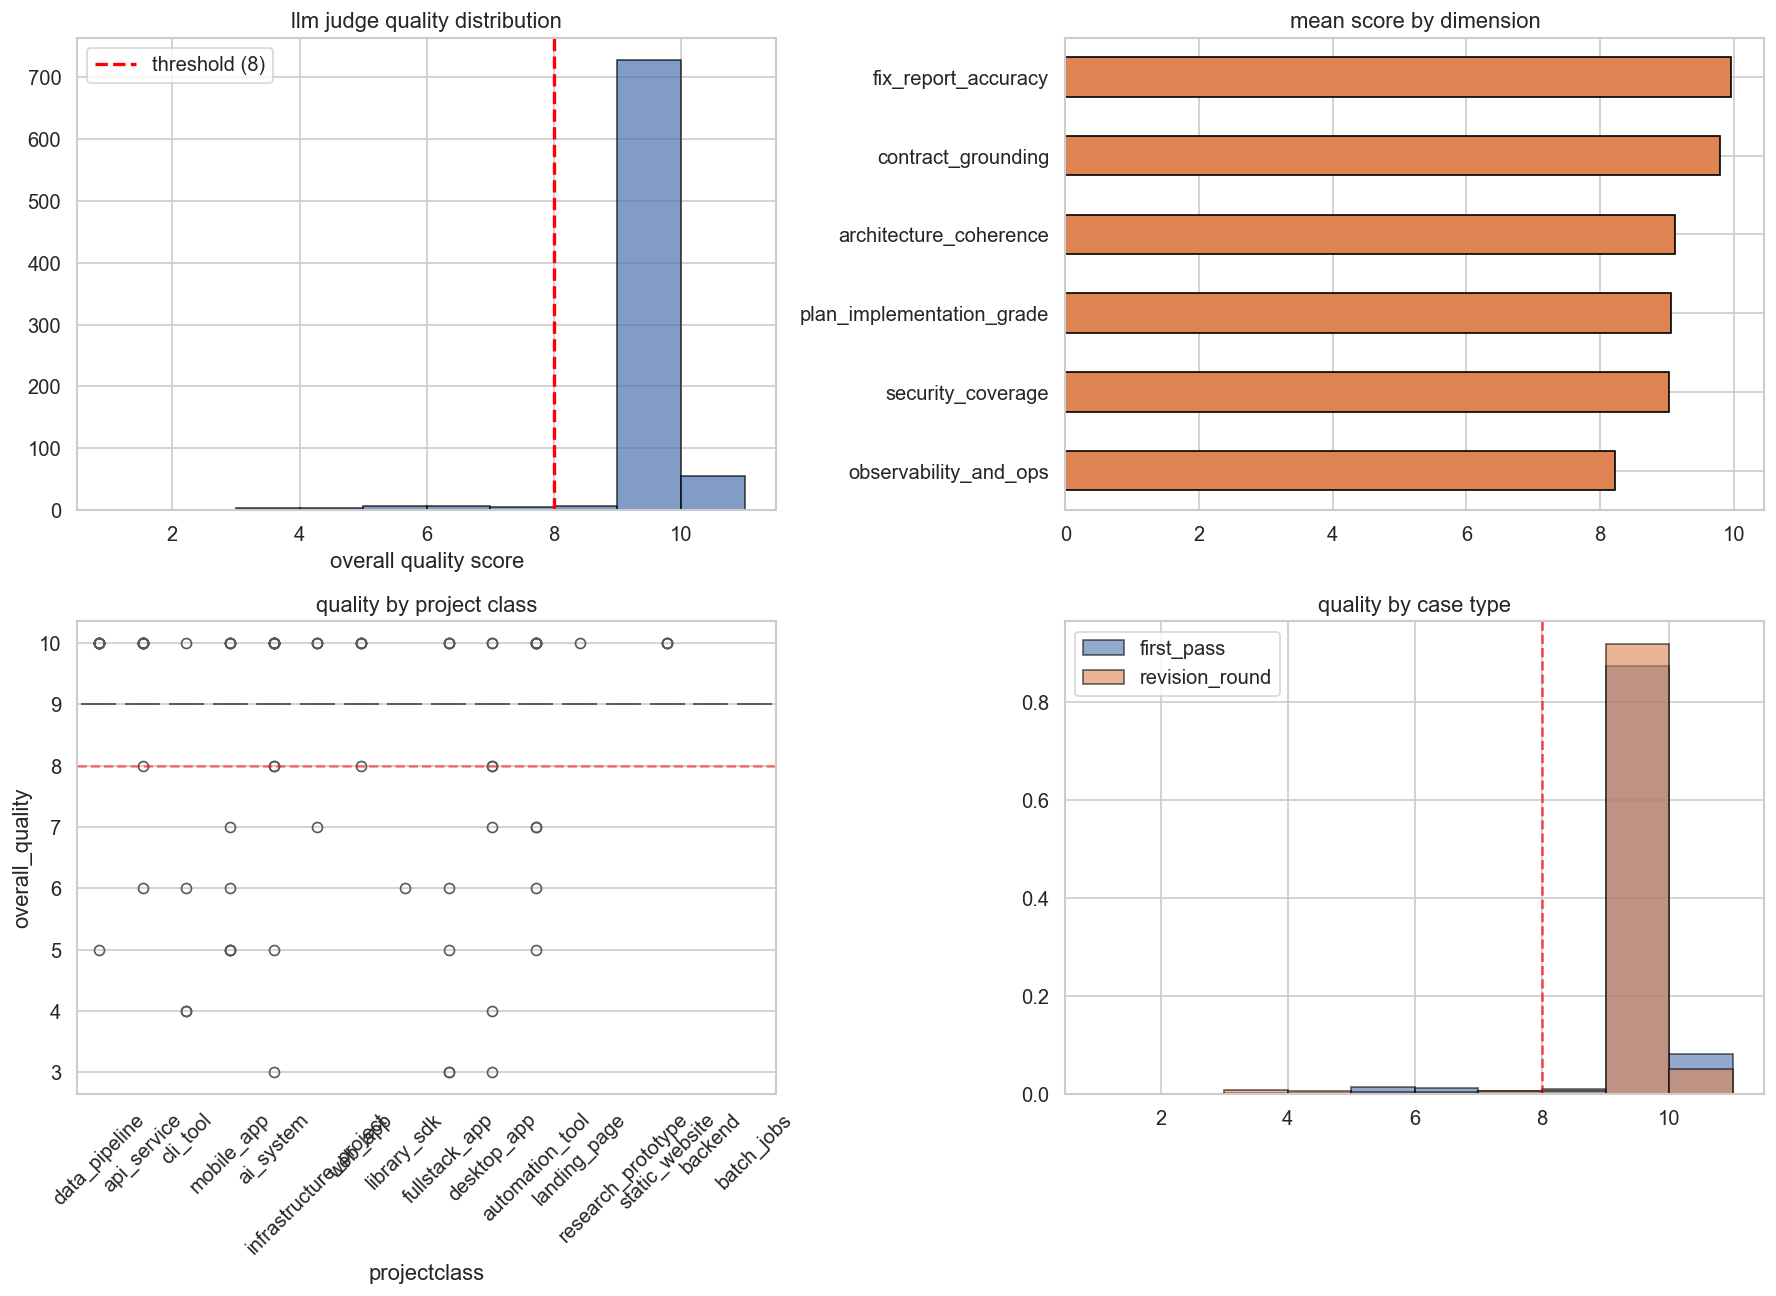


final dataset: 789 rows
project classes: {'data_pipeline': 71, 'api_service': 179, 'cli_tool': 64, 'mobile_app': 60, 'ai_system': 52, 'infrastructure_project': 41, 'web_app': 117, 'library_sdk': 39, 'fullstack_app': 42, 'automation_tool': 48, 'landing_page': 16, 'research_prototype': 16, 'desktop_app': 27, 'static_website': 15, 'backend': 1, 'batch_jobs': 1}
case types: {'first_pass': 437, 'revision_round': 352}
plan quality: {'good': 680, 'moderate': 68, 'low': 41}
saved -> validation_output\llm_as_a_judge\architect_dataset_cleaned.jsonl (10695.3 KB)


In [ ]:
import os
import time
import random
import urllib.request
import urllib.error

LLM_OUT_DIR = OUTPUT_DIR / 'llm_as_a_judge'
LLM_OUT_DIR.mkdir(exist_ok=True)

THRESHOLD = 8
LLM_SAMPLE = None

DIMS = [
    'plan_implementation_grade',
    'contract_grounding',
    'security_coverage',
    'architecture_coherence',
    'fix_report_accuracy',
    'observability_and_ops',
]

LLM_JUDGE_PROMPT = """<system_directive>
You are an Autonomous Data-Quality Gatekeeper acting as a Principal Staff Software Architect. Your sole directive is to ruthlessly evaluate a synthetic training example meant to fine-tune a Small Language Model (SLM). 
You must determine if this generated architecture plan is of sufficient implementation-grade quality to serve as "Ground Truth" training data.
</system_directive>

<cognitive_processing_pipeline>
Before assigning scores, silently execute the following validation checks:
1. The Fluff Scan: Search for generic boilerplate (e.g., "We will use a secure database"). If the plan lacks concrete, protocol-level specificity (e.g., "PostgreSQL 15 with AES-256 encryption at rest"), it is not implementation-grade.
2. The Traceability Matrix: Map every major architectural decision back to the frozen requirement contract. Ensure no unauthorized technologies were hallucinated.
3. The Coherence Check: Look for internal contradictions (e.g., claiming a stateless microservices architecture but relying on in-memory server sessions).
</cognitive_processing_pipeline>

<scoring_heuristics>
Grade the following dimensions on a strict 1 to 10 scale. Use these algorithmic anchors:

- "plan_implementation_grade": 
    [10] Highly concrete, production-ready specifications. 
    [5] Acceptable concepts but relies on generic terminology. 
    [1] Vague, high-level filler text with no technical depth.

- "contract_grounding": 
    [10] 100% traceable to the contract fields. 
    [5] Missed minor constraints but kept the core stack. 
    [1] Actively ignored the contract or hallucinated constraints.

- "security_coverage": 
    [10] Security controls perfectly match the risk/sensitivity profile (e.g., explicit mention of IAM, WAF, encryption transit/rest). 
    [5] Mentions basic security but misses edge cases. 
    [1] Dangerously exposed architecture.

- "architecture_coherence": 
    [10] Zero contradictions; data flows logically across all subsystems. 
    [5] Minor logical gaps that a senior dev would need to clarify. 
    [1] Technologically impossible or heavily contradictory design.

- "fix_report_accuracy": 
    [10] For revisions: Issue ledger maps perfectly to specific architectural changes. For first-pass: Exactly 10 if empty. 
    [5] Vague descriptions of fixes. 
    [1] Ghost fixes (claimed to fix an issue but the architecture didn't change).

- "observability_and_ops": 
    [10] Explicitly defines deployment topology, CI/CD pipelines, logging (e.g., ELK stack), and monitoring metrics. 
    [5] Mentions deployment but lacks observability depth. 
    [1] Operations and deployment are completely ignored.
</scoring_heuristics>

<verdict_thresholds>
Based on the "overall_quality" synthesis, you must output a strict classification:
- "KEEP": Overall score is 8-10. Flawless or near-flawless data.
- "NEEDS_REPAIR": Overall score is 5-7. The structure is good, but lacks specificity or has a minor hallucination.
- "REMOVE": Overall score is 1-4. Toxic training data. Fundamentally broken, vague, or contradictory.
</verdict_thresholds>

<output_constraints>
EMIT ONLY STRICT JSON. NO MARKDOWN (e.g., ```json), NO PREAMBLE.
{
    "plan_implementation_grade": <int 1-10>,
    "contract_grounding": <int 1-10>,
    "security_coverage": <int 1-10>,
    "architecture_coherence": <int 1-10>,
    "fix_report_accuracy": <int 1-10>,
    "observability_and_ops": <int 1-10>,
    "overall_quality": <int 1-10>,
    "verdict": "<KEEP|NEEDS_REPAIR|REMOVE>",
    "reason": "<Exactly one highly technical sentence explaining the primary reason for the verdict.>"
}
</output_constraints>"""
# Azure OpenAI credentials
AZURE_API_KEY = os.getenv('AZURE_OPENAI_API_KEY', 'F79rr24XOyTKAprSSVMiQuo8j99MQM9gzJD3oEIAmlfn4vrsj0TVJQQJ99CBACHYHv6XJ3w3AAABACOGX5Md')
AZURE_ENDPOINT = os.getenv('AZURE_OPENAI_ENDPOINT', 'https://cmg-ai-poc-eu2.openai.azure.com/')
AZURE_DEPLOYMENT = os.getenv('AZURE_OPENAI_CHAT_DEPLOYMENT', 'gpt-5-chat')
AZURE_API_VERSION = '2024-08-01-preview'


def llm_judge_row(row, api_key, endpoint, deployment, api_version):
    output = row.get('target_output', {})
    payload_summary = {
        'project_class': get_profile_value(row.get('profile', {}), 'project_class'),
        'case_type': row.get('metadata', {}).get('case_type', ''),
        'round': row.get('input_payload', {}).get('round', 1),
        'contract': {
            k: v.get('value', '') if isinstance(v, dict) else v
            for k, v in row.get('input_payload', {}).get('frozen_requirement_contract', {}).items()
        },
        'issue_ledger': row.get('input_payload', {}).get('issue_ledger', {}),
        'fix_report': output.get('fix_report', []),
        'plan': {
            k: str(output.get(k, ''))[:600]
            for k in ['executive_summary', 'architecture_overview', 'security_and_compliance', 'deployment_and_operations', 'risks_and_tradeoffs']
        }
    }

    url = f'{endpoint.rstrip("/")}/openai/deployments/{deployment}/chat/completions?api-version={api_version}'
    body = json.dumps({
        'messages': [
            {'role': 'system', 'content': LLM_JUDGE_PROMPT},
            {'role': 'user', 'content': json.dumps(payload_summary, indent=2)}
        ],
        'temperature': 0.1,
        'max_tokens': 512,
    }).encode()

    req = urllib.request.Request(
        url,
        data=body,
        headers={
            'Content-Type': 'application/json',
            'api-key': api_key,
        },
        method='POST'
    )

    try:
        with urllib.request.urlopen(req, timeout=30) as resp:
            resp_data = json.loads(resp.read().decode())
            text = resp_data['choices'][0]['message']['content']
            text = re.sub(r'```[\w]*\n?', '', text).strip()
            return json.loads(text)
    except Exception as e:
        return {'error': str(e)}


if AZURE_API_KEY and AZURE_ENDPOINT and cleaned_rows:
    rows_to_evaluate = cleaned_rows
    if LLM_SAMPLE:
        rows_to_evaluate = random.sample(cleaned_rows, min(LLM_SAMPLE, len(cleaned_rows)))

    print(f'running llm judge on {len(rows_to_evaluate)} rows')
    print(f'endpoint: {AZURE_ENDPOINT}')
    print(f'deployment: {AZURE_DEPLOYMENT}')

    llm_scores = []
    start_time = time.time()

    for idx, row in enumerate(rows_to_evaluate):
        result = llm_judge_row(row, AZURE_API_KEY, AZURE_ENDPOINT, AZURE_DEPLOYMENT, AZURE_API_VERSION)
        if result and 'overall_quality' in result:
            result['sample_id'] = row.get('sample_id', '')
            result['projectclass'] = get_profile_value(row.get('profile', {}), 'project_class')
            result['case_type'] = row.get('metadata', {}).get('case_type', '')
            llm_scores.append(result)

        score = result.get('overall_quality', 0)
        verdict = result.get('verdict', 'ERROR')
        print(f'[{idx+1}/{len(rows_to_evaluate)}] {row.get("sample_id", "")}: {score}/10 | {verdict}')

        if (idx + 1) % 50 == 0:
            elapsed = time.time() - start_time
            rate = (idx + 1) / elapsed * 60
            remaining = (len(rows_to_evaluate) - idx - 1) / (rate / 60)
            print(f'  {idx+1} done — {rate:.1f} rows/min, ~{remaining/60:.0f} min remaining')

        time.sleep(0.3)

    llm_df = pd.DataFrame(llm_scores)

    print(f'\nevaluated: {len(llm_df)} rows')
    if 'overall_quality' in llm_df.columns:
        print(f'mean overall quality: {llm_df["overall_quality"].mean():.2f}')
        print(f'rows at or above threshold ({THRESHOLD}): {(llm_df["overall_quality"] >= THRESHOLD).sum()} ({(llm_df["overall_quality"] >= THRESHOLD).mean()*100:.1f}%)')
        print('\ndimension means:')
        for dim in DIMS:
            if dim in llm_df.columns:
                print(f'  {dim}: {llm_df[dim].mean():.2f}')

    llm_df.to_csv(LLM_OUT_DIR / 'llm_judge_scores.csv', index=False)

    if 'sample_id' in llm_df.columns:
        keep_ids = set(llm_df[llm_df['overall_quality'] >= THRESHOLD]['sample_id'].tolist())
        final_rows = [r for r in cleaned_rows if r.get('sample_id') in keep_ids]
    else:
        final_rows = cleaned_rows

    if len(llm_df) > 5:
        fig, axes = plt.subplots(2, 2, figsize=(15, 11))
        axes[0, 0].hist(llm_df['overall_quality'], bins=range(1, 12), edgecolor='black', alpha=0.7, color='#4C72B0')
        axes[0, 0].axvline(THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'threshold ({THRESHOLD})')
        axes[0, 0].set_xlabel('overall quality score')
        axes[0, 0].set_title('llm judge quality distribution')
        axes[0, 0].legend()
        dim_means = {d: llm_df[d].mean() for d in DIMS if d in llm_df.columns}
        pd.Series(dim_means).sort_values().plot(kind='barh', ax=axes[0, 1], color='#DD8452', edgecolor='black')
        axes[0, 1].set_title('mean score by dimension')
        if 'projectclass' in llm_df.columns and llm_df['projectclass'].nunique() > 1:
            sns.boxplot(data=llm_df, x='projectclass', y='overall_quality', ax=axes[1, 0], palette='Set2')
            axes[1, 0].set_title('quality by project class')
            axes[1, 0].tick_params(axis='x', rotation=45)
            axes[1, 0].axhline(THRESHOLD, color='red', linestyle='--', alpha=0.5)
        if 'case_type' in llm_df.columns:
            for ct, grp in llm_df.groupby('case_type'):
                axes[1, 1].hist(grp['overall_quality'], bins=range(1, 12), alpha=0.6, edgecolor='black', label=ct, density=True)
            axes[1, 1].set_title('quality by case type')
            axes[1, 1].axvline(THRESHOLD, color='red', linestyle='--', alpha=0.7)
            axes[1, 1].legend()
        plt.tight_layout()
        plt.savefig(LLM_OUT_DIR / 'llm_quality_analysis.png', bbox_inches='tight')
        plt.show()

else:
    print('llm judge skipped — set AZURE_OPENAI_API_KEY and AZURE_OPENAI_ENDPOINT to enable')
    print('using all cleaned rows as final dataset')
    final_rows = cleaned_rows
    llm_df = pd.DataFrame()

if final_rows:
    final_pc = Counter(get_profile_value(r.get('profile', {}), 'project_class') for r in final_rows)
    final_ct = Counter(r.get('metadata', {}).get('case_type', '') for r in final_rows)
    final_pq = Counter(r.get('metadata', {}).get('plan_quality', '') for r in final_rows)
    print(f'\nfinal dataset: {len(final_rows)} rows')
    print(f'project classes: {dict(final_pc)}')
    print(f'case types: {dict(final_ct)}')
    print(f'plan quality: {dict(final_pq)}')

    INTERIM_PATH = str(LLM_OUT_DIR / 'architect_dataset_cleaned.jsonl')
    with open(INTERIM_PATH, 'w', encoding='utf-8') as f:
        for row in final_rows:
            f.write(json.dumps(row, ensure_ascii=False) + '\n')
    print(f'saved -> {INTERIM_PATH} ({Path(INTERIM_PATH).stat().st_size / 1024:.1f} KB)')

## 16 — Final Key Normalization

Maps any remaining camelCase or compact `target_output` keys to the exact snake_case names that `main.py`'s `normalize_plan()` reads. Also normalizes `frozen_requirement_contract` field keys and `fix_report` item keys. This is the same pattern as the AuditorAgent pipeline's final cell.

In [18]:
INPUT_PATH = str(LLM_OUT_DIR / 'architect_dataset_cleaned.jsonl')
OUTPUT_PATH = str(LLM_OUT_DIR / 'architect_dataset_final.jsonl')

# target_output key remap — any compact/camelCase form -> snake_case (main.py canonical)
TARGET_OUTPUT_KEY_MAP = {
    'thinkingsummary': 'thinking_summary',
    'fixreport': 'fix_report',
    'executivesummary': 'executive_summary',
    'architectureoverview': 'architecture_overview',
    'technologystack': 'technology_stack',
    'functionalfeaturemap': 'functional_feature_map',
    'systemcomponents': 'system_components',
    'datamodel': 'data_model',
    'apidesign': 'api_design',
    'securityandcompliance': 'security_and_compliance',
    'deploymentandoperations': 'deployment_and_operations',
    'costandscaling': 'cost_and_scaling',
    'phasedimplementation': 'phased_implementation',
    'developmentguidelines': 'development_guidelines',
    'risksandtradeoffs': 'risks_and_tradeoffs',
    'openquestionsresolved': 'open_questions_resolved',
}

FIX_REPORT_KEY_MAP = {
    'issueid': 'issue_id',
    'actiontaken': 'action_taken',
    'changedsections': 'changed_sections',
    'expectedoutcome': 'expected_outcome',
}

CONTRACT_KEY_MAP = {
    'projectgoal': 'project_goal',
    'targetusers': 'target_users',
    'projectclass': 'project_class',
    'complexitylevel': 'complexity_level',
    'risklevel': 'risk_level',
    'datasensitivity': 'data_sensitivity',
    'externalexposure': 'external_exposure',
    'accessmodel': 'access_model',
    'featurescope': 'feature_scope',
    'mvpscope': 'mvp_scope',
    'securitybaseline': 'security_baseline',
    'frontendstack': 'frontend_stack',
    'backendstack': 'backend_stack',
    'dataplatform': 'data_platform',
    'hostingtarget': 'hosting_target',
    'privacyretentionpolicy': 'privacy_retention_policy',
    'futurescope': 'future_scope',
    'observabilitybaseline': 'observability_baseline',
    'executionpreference': 'execution_preference',
    'llmintegration': 'llm_integration',
    'compliancecontext': 'compliance_context',
}


def remap_keys(d, key_map):
    return {key_map.get(k, k): v for k, v in d.items()}


def normalize_fix_report(fix_report):
    if not isinstance(fix_report, list):
        return []
    result = []
    for item in fix_report:
        if isinstance(item, dict):
            item = remap_keys(item, FIX_REPORT_KEY_MAP)
            if 'changed_sections' in item and not isinstance(item['changed_sections'], list):
                item['changed_sections'] = [str(item['changed_sections'])]
            result.append(item)
    return result


def normalize_target_output(target):
    target = remap_keys(target, TARGET_OUTPUT_KEY_MAP)
    if 'fix_report' in target:
        target['fix_report'] = normalize_fix_report(target['fix_report'])
    target.pop('generated_at', None)
    for key in MANDATORY_PLAN_KEYS:
        if key not in target:
            target[key] = [] if key in ('fix_report', 'open_questions_resolved') else ''
    for leak_key in AUDITOR_LEAK_KEYS:
        target.pop(leak_key, None)
    return target


def normalize_frozen_contract(contract):
    if not isinstance(contract, dict):
        return contract
    contract = remap_keys(contract, CONTRACT_KEY_MAP)
    subkey_map = {'updatedat': 'updated_at'}
    for field_name, field_obj in contract.items():
        if isinstance(field_obj, dict):
            contract[field_name] = remap_keys(field_obj, subkey_map)
            val = contract[field_name].get('value', '')
            if isinstance(val, str) and val in COMPACT_VALUE_MAP:
                contract[field_name]['value'] = COMPACT_VALUE_MAP[val]
    return contract


def normalize_row(row):
    row = copy.deepcopy(row)
    if 'target_output' in row and isinstance(row['target_output'], dict):
        row['target_output'] = normalize_target_output(row['target_output'])
    if 'input_payload' in row and isinstance(row['input_payload'], dict):
        contract = row['input_payload'].get('frozen_requirement_contract', {})
        row['input_payload']['frozen_requirement_contract'] = normalize_frozen_contract(contract)
    if 'profile' in row and isinstance(row['profile'], dict):
        row['profile'] = normalize_profile_keys(row['profile'])
        row['profile'] = normalize_profile_values(row['profile'])
    if 'metadata' in row and isinstance(row['metadata'], dict):
        row['metadata'] = normalize_plan_quality(row['metadata'])
    return row


norm_rows = []
with open(INPUT_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                norm_rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f'skip bad line: {e}')

print(f'loaded {len(norm_rows)} rows')

fixed_rows = [normalize_row(r) for r in norm_rows]
print(f'normalized {len(fixed_rows)} rows')

# Final compliance check against main.py requirements
missing_keys_count = sum(1 for r in fixed_rows if set(MANDATORY_PLAN_KEYS) - set(r.get('target_output', {}).keys()))
audit_leak_count = sum(1 for r in fixed_rows if any(k in r.get('target_output', {}) for k in AUDITOR_LEAK_KEYS))
bad_pq_count = sum(1 for r in fixed_rows if r.get('metadata', {}).get('plan_quality', '') not in ALLOWED_PLAN_QUALITY)
bad_profile_pc = sum(1 for r in fixed_rows if get_profile_value(r.get('profile', {}), 'project_class') not in ALLOWED_PROJECT_CLASSES)
bad_profile_exp = sum(1 for r in fixed_rows if get_profile_value(r.get('profile', {}), 'external_exposure') not in ALLOWED_EXPOSURE)
compact_keys_remain = sum(1 for r in fixed_rows if any(k in r.get('profile', {}) for k in PROFILE_KEY_MAP.keys()))

sample_out = fixed_rows[0].get('target_output', {})
print(f'\nsample target_output keys: {sorted(sample_out.keys())}')
print(f'sample fix_report items: {len(sample_out.get("fix_report", []))}')
if sample_out.get('fix_report') and isinstance(sample_out['fix_report'][0], dict):
    print(f'sample fix_report[0] keys: {sorted(sample_out["fix_report"][0].keys())}')

print(f'\nmissing required plan keys: {missing_keys_count}')
print(f'auditor key leaks: {audit_leak_count}')
print(f'invalid plan_quality: {bad_pq_count}')
print(f'invalid profile project_class: {bad_profile_pc}')
print(f'invalid profile external_exposure: {bad_profile_exp}')
print(f'compact profile keys remaining: {compact_keys_remain}')

all_zero = all(v == 0 for v in [missing_keys_count, audit_leak_count, bad_pq_count, bad_profile_pc, bad_profile_exp, compact_keys_remain])
print(f'\nall checks passed: {all_zero}')

with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    for row in fixed_rows:
        f.write(json.dumps(row, ensure_ascii=False) + '\n')

size_kb = Path(OUTPUT_PATH).stat().st_size / 1024
print(f'\nsaved -> {OUTPUT_PATH} ({size_kb:.1f} KB)')
print(f'rows: {len(fixed_rows)}')
print(f'project classes: {dict(Counter(get_profile_value(r.get("profile", {}), "project_class") for r in fixed_rows))}')
print(f'case types: {dict(Counter(r.get("metadata", {}).get("case_type", "") for r in fixed_rows))}')
print(f'plan quality: {dict(Counter(r.get("metadata", {}).get("plan_quality", "") for r in fixed_rows))}')

loaded 789 rows
normalized 789 rows

sample target_output keys: ['api_design', 'architecture_overview', 'cost_and_scaling', 'data_model', 'deployment_and_operations', 'development_guidelines', 'executive_summary', 'fix_report', 'functional_feature_map', 'observability', 'open_questions_resolved', 'phased_implementation', 'risks_and_tradeoffs', 'security_and_compliance', 'system_components', 'technology_stack', 'thinking_summary', 'title', 'workflows']
sample fix_report items: 0

missing required plan keys: 0
auditor key leaks: 0
invalid plan_quality: 0
invalid profile project_class: 2
invalid profile external_exposure: 0
compact profile keys remaining: 0

all checks passed: False

saved -> validation_output\llm_as_a_judge\architect_dataset_final.jsonl (10695.4 KB)
rows: 789
project classes: {'data_pipeline': 71, 'api_service': 179, 'cli_tool': 64, 'mobile_app': 60, 'ai_system': 52, 'infrastructure_project': 41, 'web_app': 117, 'library_sdk': 39, 'fullstack_app': 42, 'automation_tool': 